# Positive selection

In this exercise, we will use simulations to build intuition for how genetic drift and natural selection shape allele frequencies in finite populations. We will start from the simplest case -- a neutral allele drifting in a finite population -- and gradually layer on mutation and selection to see how each force changes the picture.

The central simulation tool is a Wright-Fisher model: each generation, the number of copies of an allele is drawn from a binomial distribution, where the expected frequency depends on the current frequency and the selection coefficient $s$. This is the simplest model that captures both genetic drift (random sampling of gametes) and directional selection.

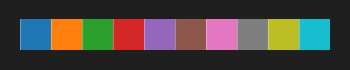

In [11]:
%matplotlib inline
from sys import platform

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D, get_test_data
from matplotlib import cm
from matplotlib.patches import Rectangle
import math
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pd 
from pathlib import Path
import platform
from multiprocess import Pool
from vscodenb import set_vscode_theme, vscode_theme
 
n_cpus = int(os.environ.get('SLURM_CPUS_PER_TASK', 1)) if platform.system() == 'Linux' else os.cpu_count()

# def freq_trajectory(N, n=1, s=0):
#     yield n
#     while N > n > 0:
#         n = np.random.binomial(N, n*(1+s) / ((N-n) + n*(1+s) ), 1)[0].item()        
#         yield n

def _freq_trajectory_generator(N, n, s, rng):
    yield n
    while N > n > 0:
        n = rng.binomial(N, n*(1+s) / ((N-n) + n*(1+s) ), 1)[0].item()        
        yield n

def _freq_trajectory(N, n=1, s=0, rng=None):
    return list(_freq_trajectory_generator(N, n=n, s=s, rng=rng))

def freq_trajectory(N, n=1, s=0, replicates=1):
    if replicates == 1:
        rng = np.random.default_rng(12345)
        return _freq_trajectory(N, n=n, s=s, rng=rng)
    else:
        with Pool(n_cpus) as p:
            args = [(N, n, s, np.random.default_rng(12345 + i)) for i in range(replicates)]
            res = p.starmap(_freq_trajectory, args)
        return res
    

def tight(fig):
    fig.canvas.header_visible = False
    plt.tight_layout()

%config InlineBackend.figure_format = 'retina'
set_vscode_theme()
sns.set_palette('tab10')
#plt.set_cmap('tab10')
sns.palplot(sns.color_palette(), size=0.2)



## Allele frequency of a neutral allele

Consider an allele that starts at a frequency of 50% in a population of $N = 1000$ (i.e. 500 out of 1000 gene copies carry the allele). With no selection ($s = 0$), the allele frequency wanders up and down at random. Each generation is like flipping a slightly biased coin -- the bias is just the current frequency -- so the trajectory is unpredictable. Rerun the cell below to see different outcomes:

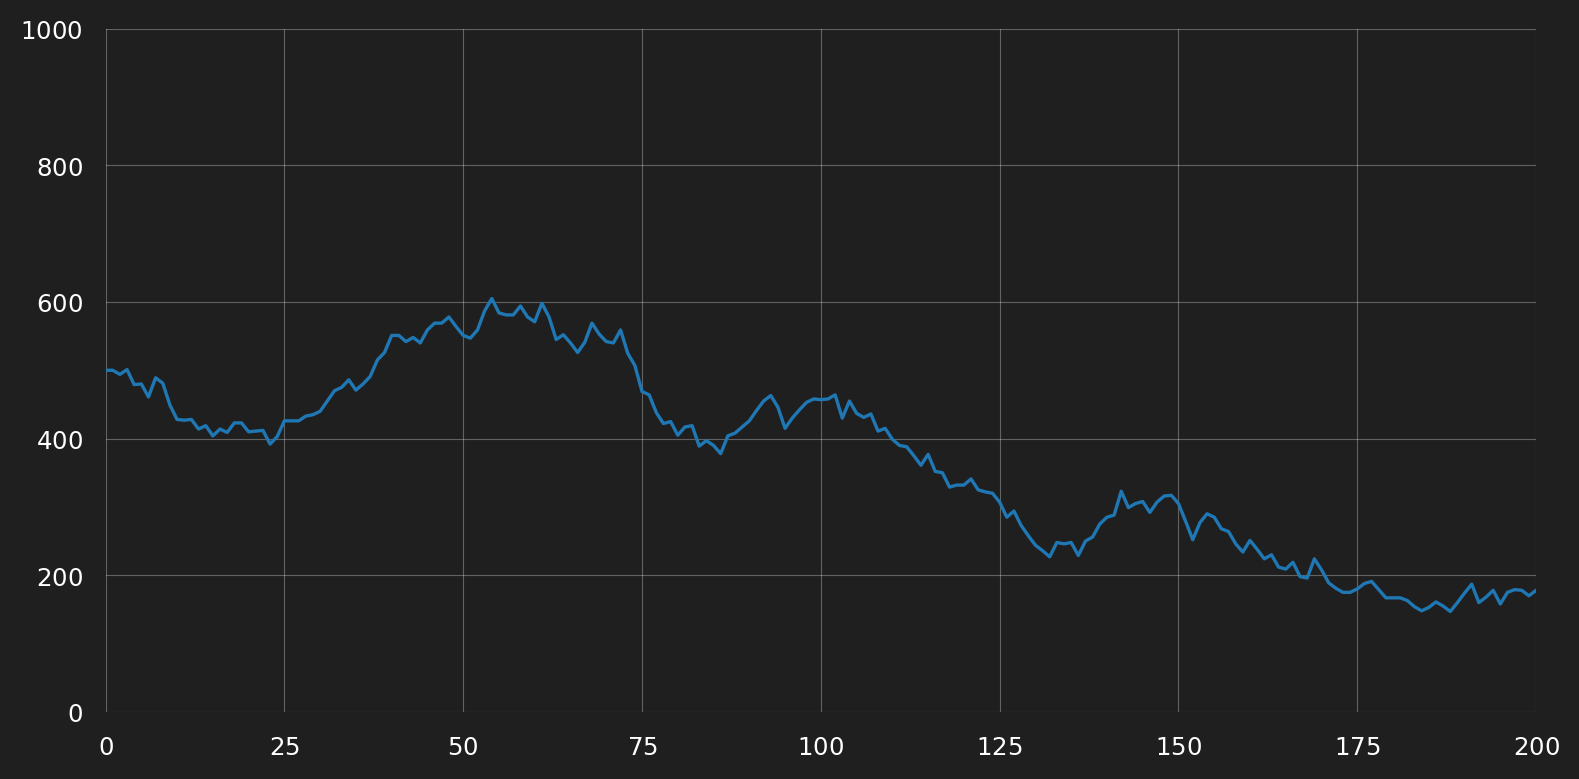

In [12]:
# Number of haploid individuals with the allele
n = 500
# Population size
N = 1000
# selection coeficient
s = 0.0

fig = plt.figure(figsize=(8, 4))
for i in range(1):
    plt.plot(list(freq_trajectory(N, n=n, s=s)))
plt.xlim(0, 200)
plt.ylim(0, N)
tight(fig)
plt.show()

A single trajectory can be misleading because drift is inherently stochastic. To appreciate the range of possible outcomes, we plot many independent realisations from the same starting point. Notice how some trajectories drift upward, others downward -- each run is a different possible evolutionary history for the same allele under the same conditions:

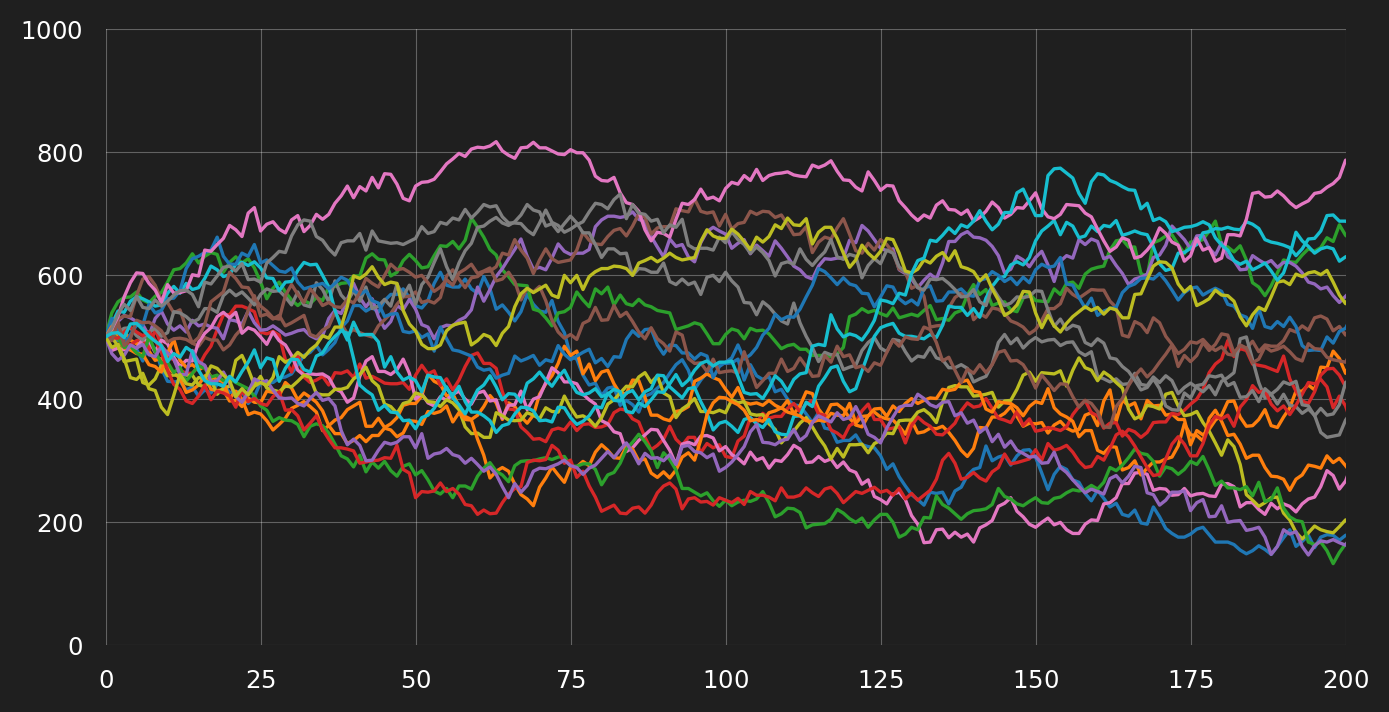

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_xlim(0, 200)
ax.set_ylim(0, N)

s = 0.0
trajectories = freq_trajectory(N, n=n, s=s, replicates=20)
for trajectory in trajectories:
    ax.plot(trajectory)

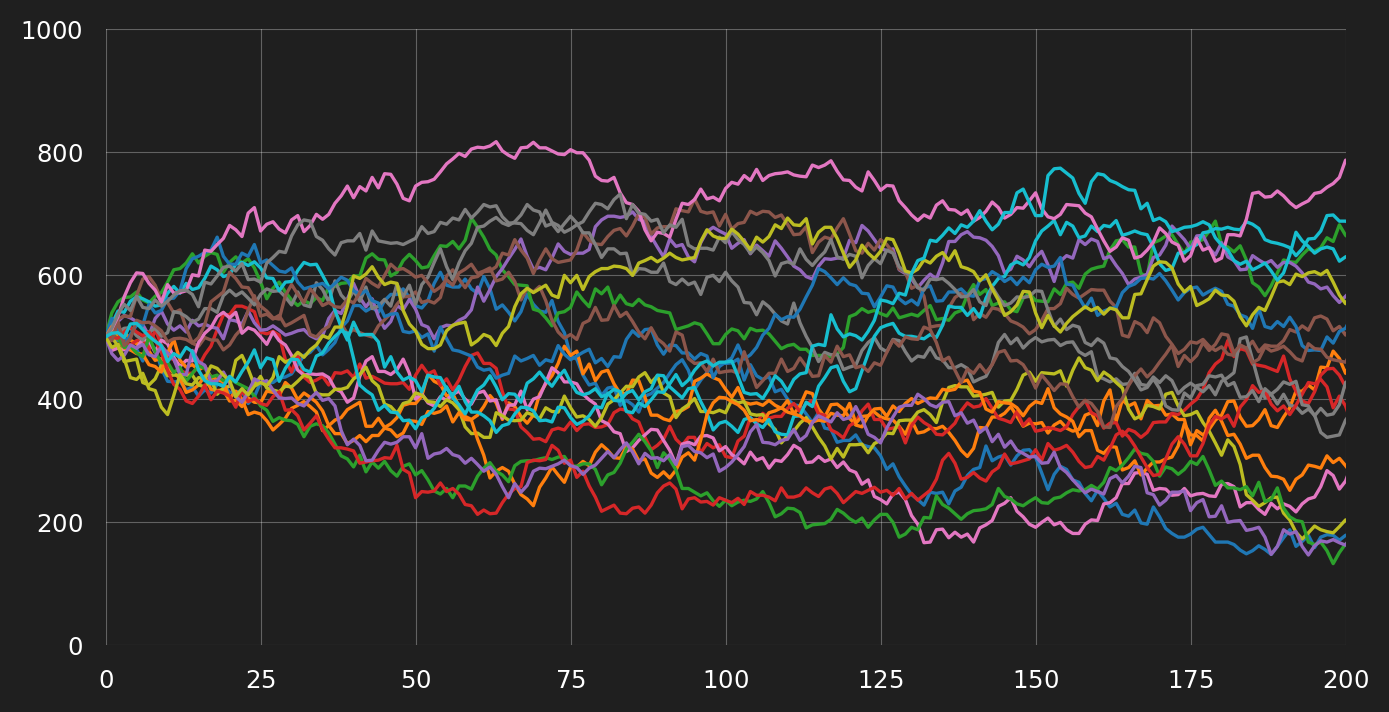

In [14]:
fig = plt.figure(figsize=(8, 4))
plt.xlim(0, 200)
plt.ylim(0, N)

s = 0.0
for trajectory in freq_trajectory(N, n=n, s=s, replicates=20):
    plt.plot(trajectory)

### The effect of population size on drift

Population size is the key parameter controlling the strength of genetic drift. In a small population, allele frequencies fluctuate wildly from generation to generation because the sampling variance is large relative to $N$. In a large population, the same sampling process produces much smaller fluctuations. The plots below compare 20 trajectories for $N = 1000$ (top) and $N = 10{,}000$ (bottom) over the same number of generations. Both start at 50% frequency:

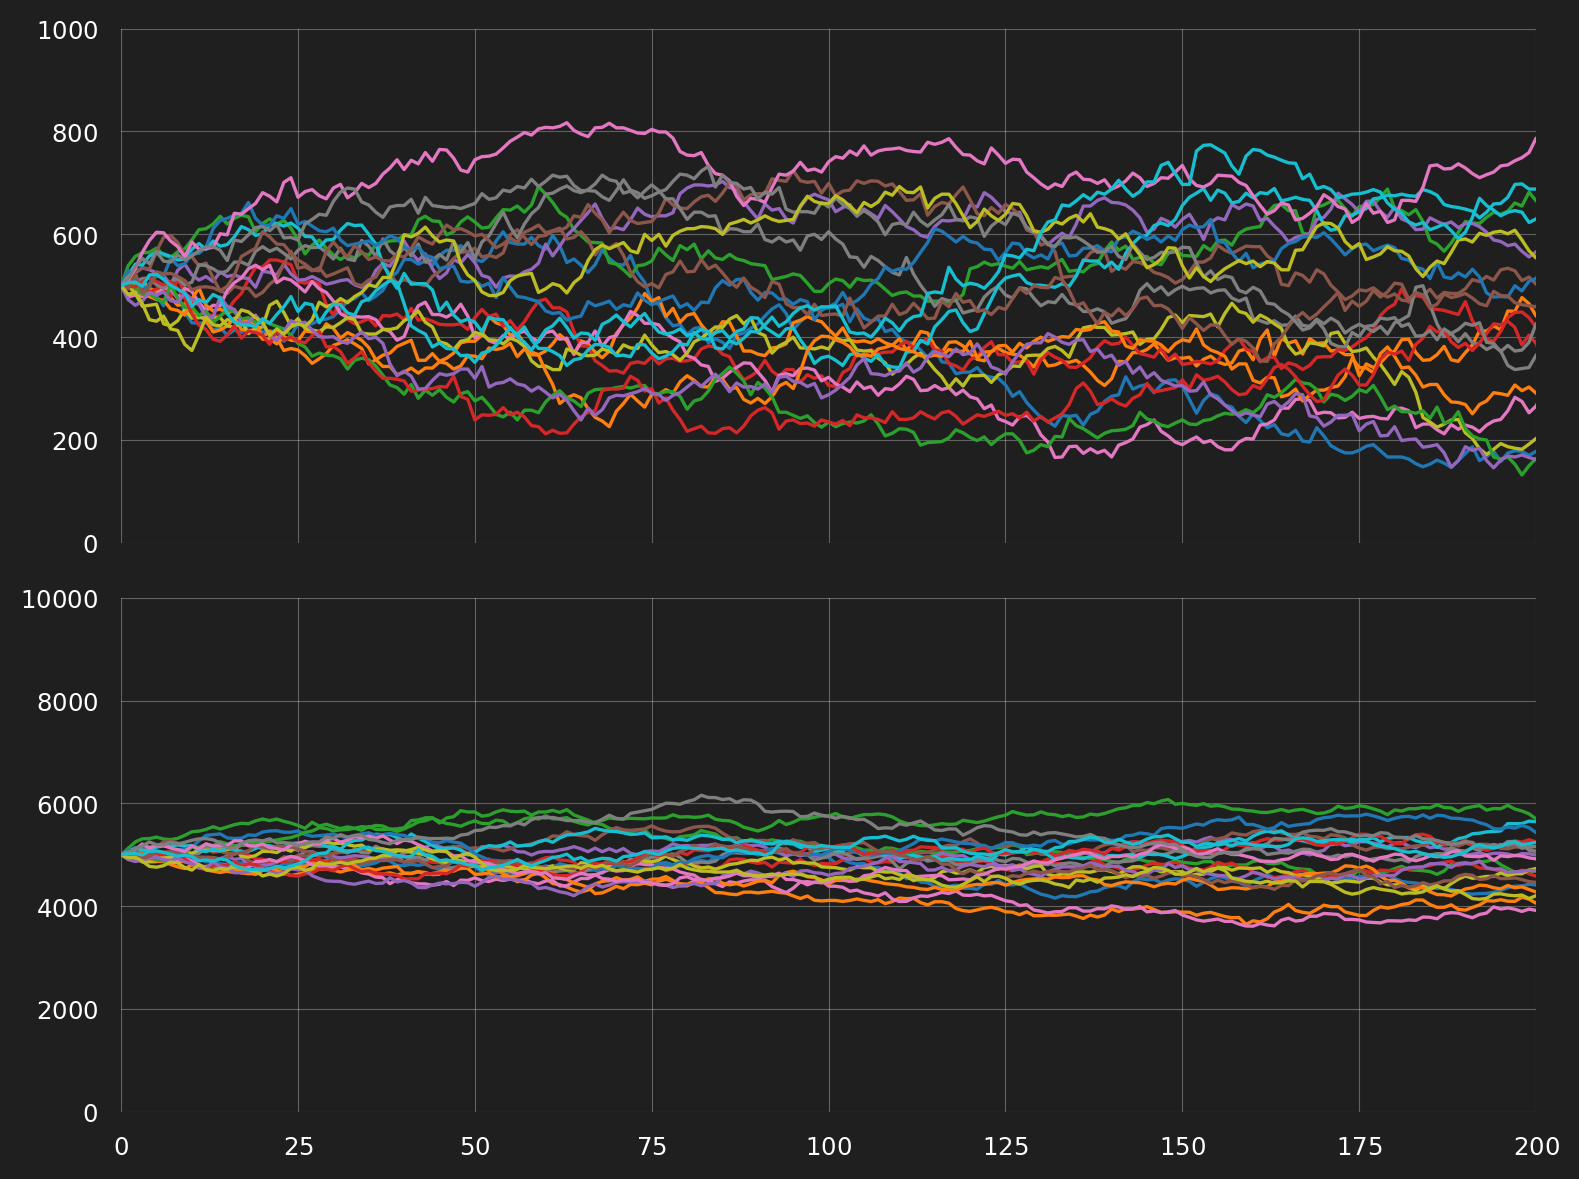

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
plt.xlim(0, 200)
ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 10000)
s = 0.0
for trajectory in freq_trajectory(1000, n=500, s=s, replicates=20):
    ax1.plot(trajectory)
for trajectory in freq_trajectory(10000, n=5000, s=s, replicates=20):
    ax2.plot(trajectory)
plt.tight_layout()

### Time to loss or fixation

Every neutral allele in a finite population will eventually be either lost (frequency reaches 0) or fixed (frequency reaches $N$) -- these are the only absorbing states. The question is not *if*, but *when*. The expected time to fixation or loss scales with the population size: in the smaller population ($N = 1000$, top), alleles tend to reach fixation or loss within a few thousand generations, while in the larger population ($N = 10{,}000$, bottom) the process takes roughly ten times as long. This is because the expected time to fixation of a neutral allele starting at frequency $p$ is $\bar{t} \approx -4N p \ln(p) / (1-p)$ generations, which scales linearly with $N$.

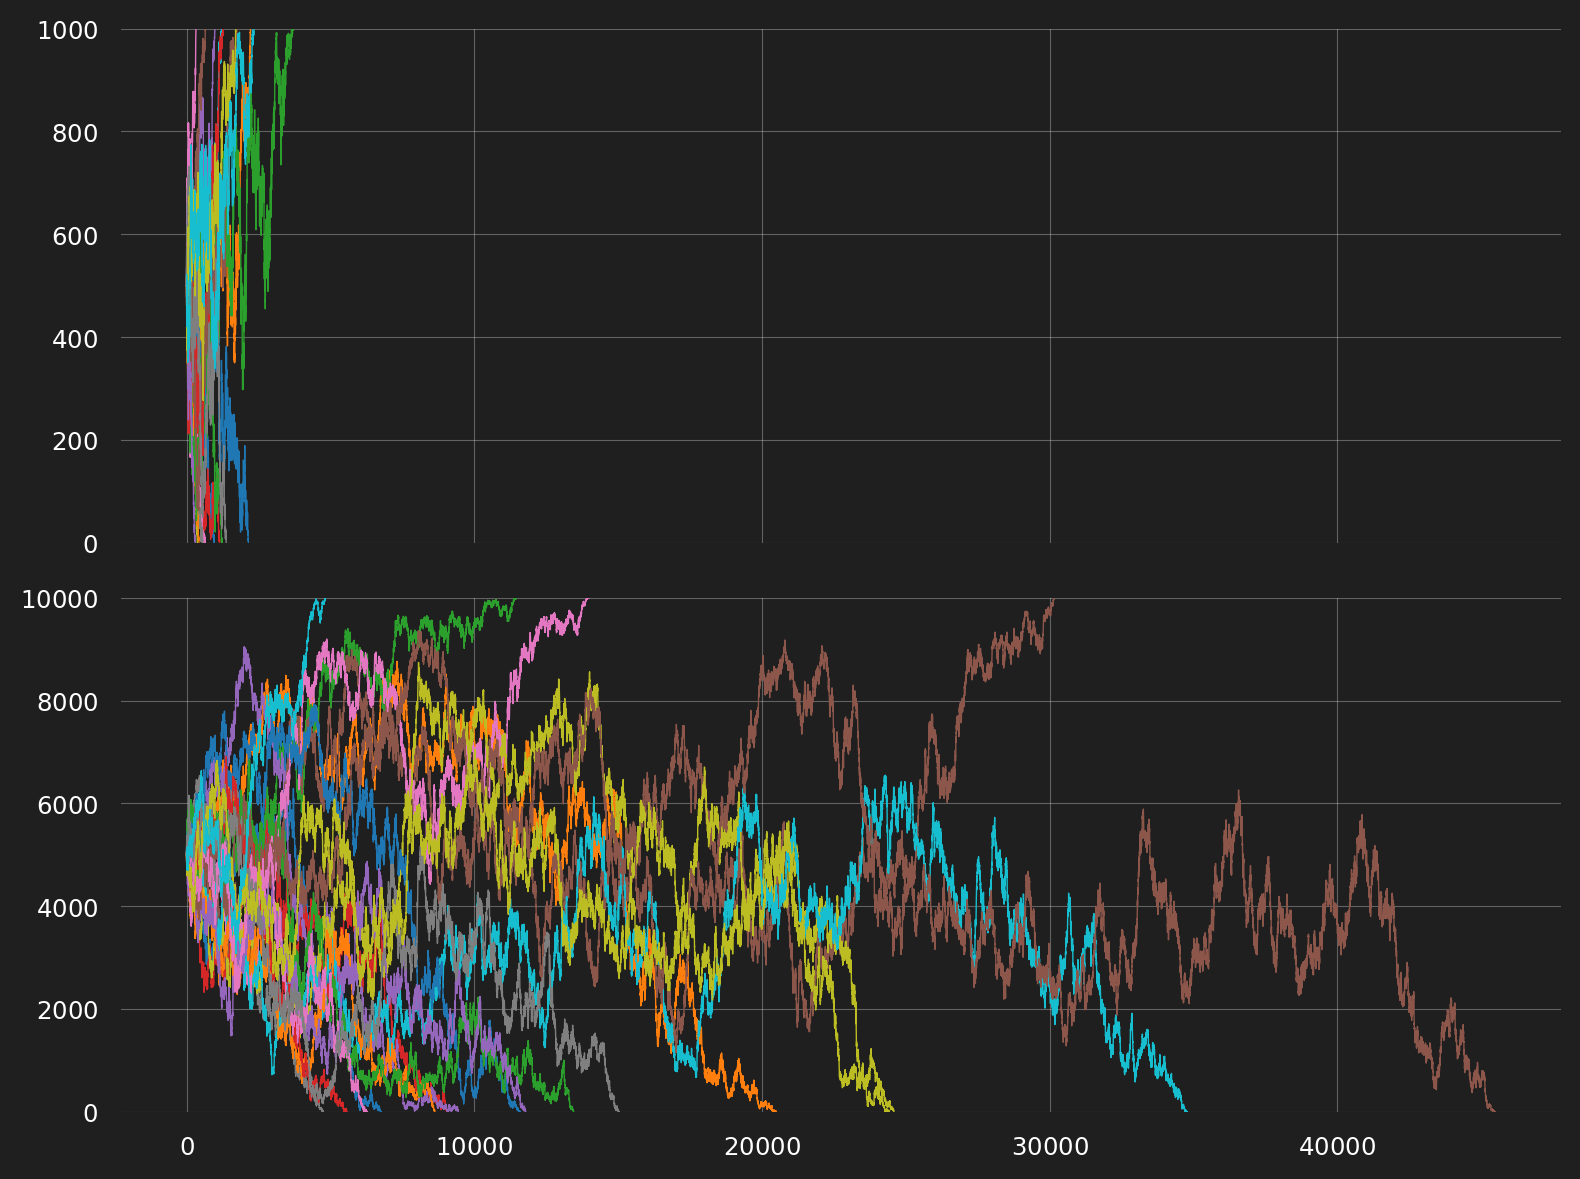

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 10000)
s = 0.0
for trajectory in freq_trajectory(1000, n=500, s=s, replicates=20):
    ax1.plot(trajectory, lw=0.5)
for trajectory in freq_trajectory(10000, n=5000, s=s, replicates=20):
    ax2.plot(trajectory, lw=0.5)

tight(fig)      

## Positive selection

We now introduce selection. A new mutation with selective advantage $s > 0$ has a higher expected frequency in the next generation than a neutral allele at the same frequency. But selection is not deterministic -- especially when the allele is rare, stochastic loss is very likely because drift dominates at low copy numbers. The critical question is: how large must $s$ be, relative to the strength of drift ($\sim 1/N$), for selection to reliably drive an allele to fixation?

Below we simulate 1000 new mutations, each starting from a single copy ($n = 1$) in a population of $N = 1000$, with a selective advantage of $s = 0.1$ (so $Ns = 100$, which is strong selection). Despite this substantial advantage, the vast majority of mutations are lost within the first few generations. Only a small fraction escape initial drift and rise to fixation. This is because when an allele exists as just one or a few copies, drift variance is comparable to or larger than the selective advantage. Use the Zoom tool on the figure to zoom in on the bottom left corner of the plot to see the many alleles that are lost.

In [ ]:
%matplotlib widget
n = 1
N = 1000
s = 0.05
print(f"Ns = {N*s}")
fig = plt.figure(figsize=(7, 4))
plt.ylim(0, N)
for trajectory in freq_trajectory(1000, n=n, s=s, replicates=1000):
    plt.plot(trajectory, lw=0.5)

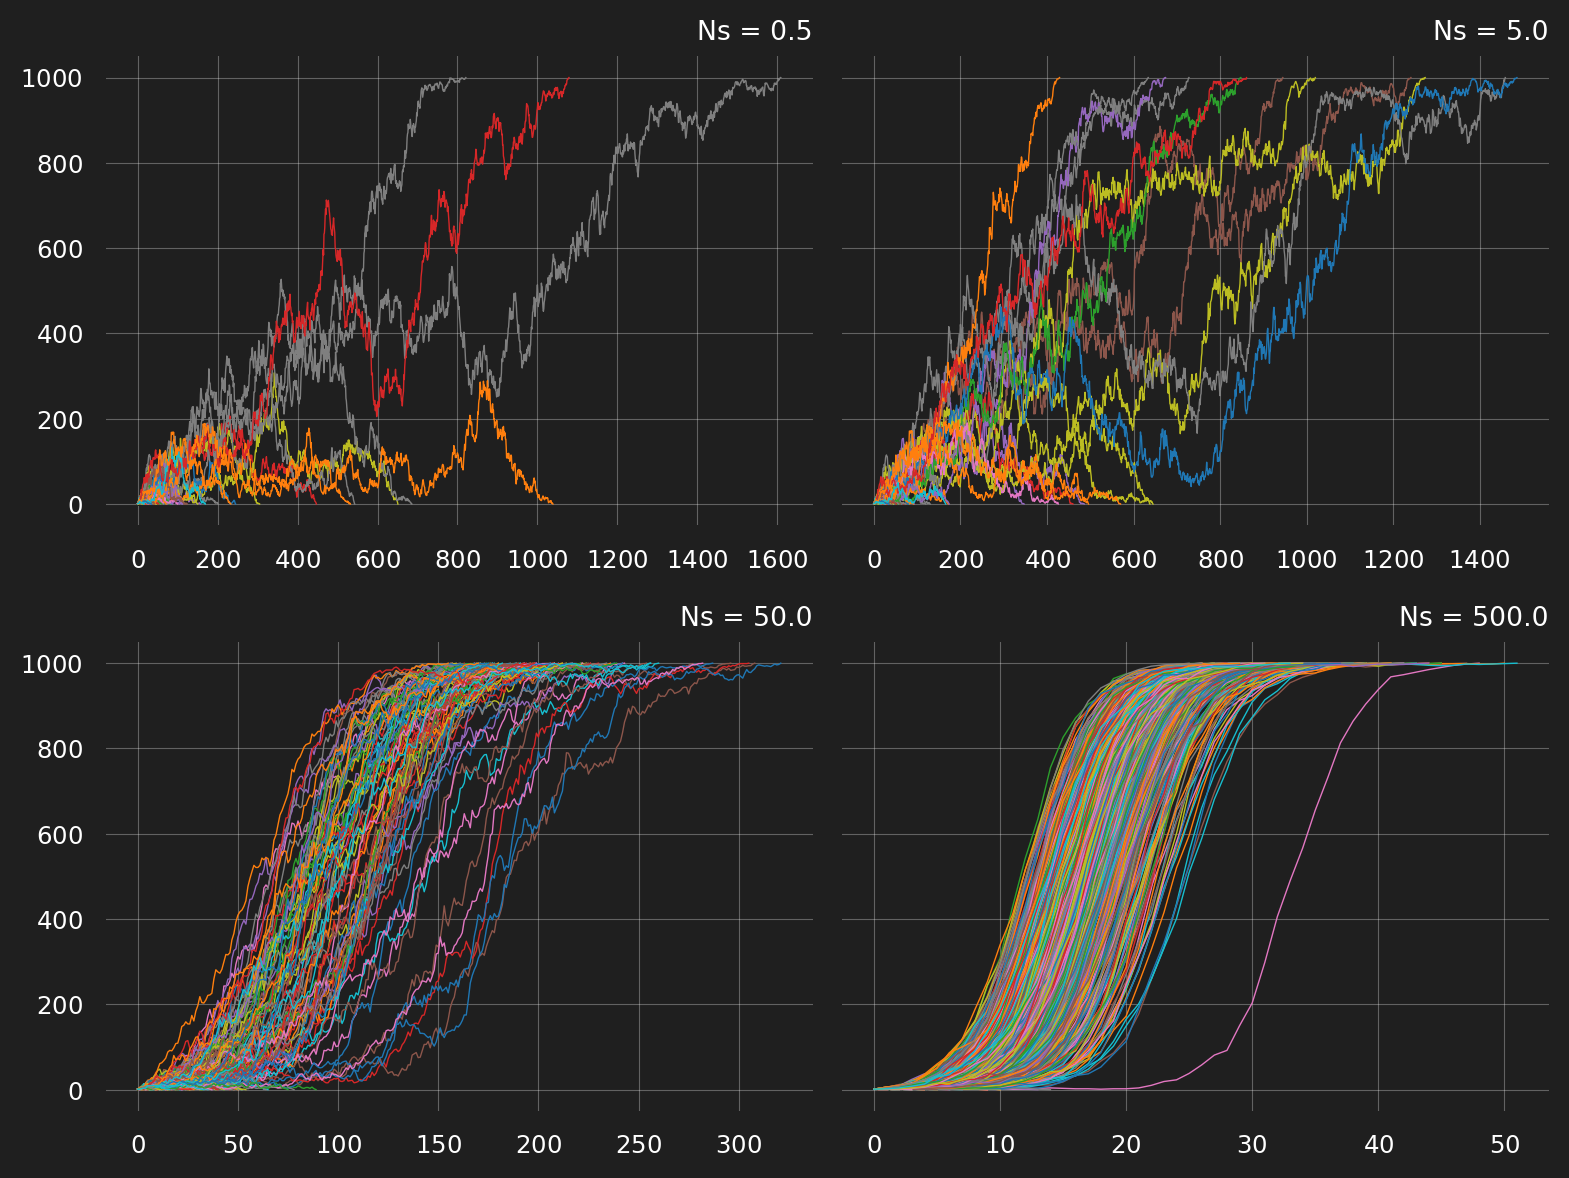

In [ ]:
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=True)
n = 1
N = 1000
for s, ax in zip([0.0005, 0.005, 0.05, 0.5], axes.flat):
    for trajectory in freq_trajectory(1000, n=n, s=s, replicates=1000):
        ax.plot(trajectory, lw=0.5)
        ax.set_title(f"Ns = {N*s}")
plt.tight_layout()

Ns = 50.0


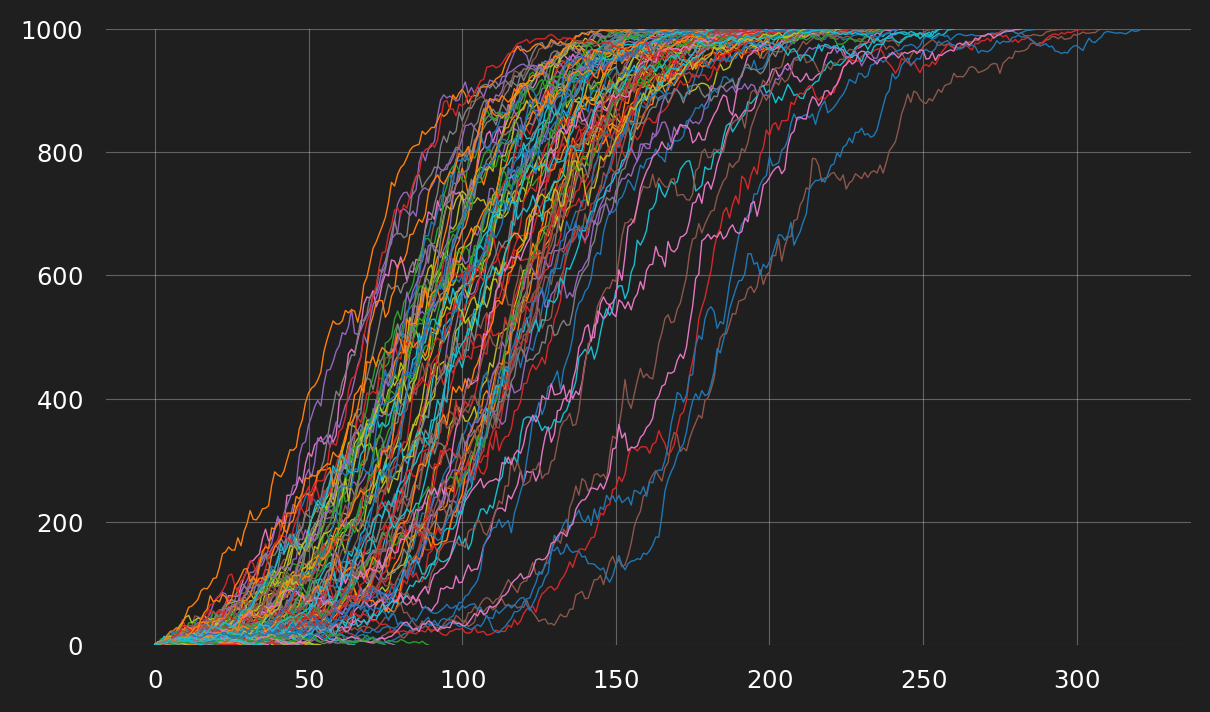

In [40]:
n = 1
N = 1000
s = 0.05
print(f"Ns = {N*s}")
fig = plt.figure(figsize=(7, 4))
plt.ylim(0, N)
for trajectory in freq_trajectory(1000, n=n, s=s, replicates=1000):
    plt.plot(trajectory, lw=0.5)

Ns = 500.0


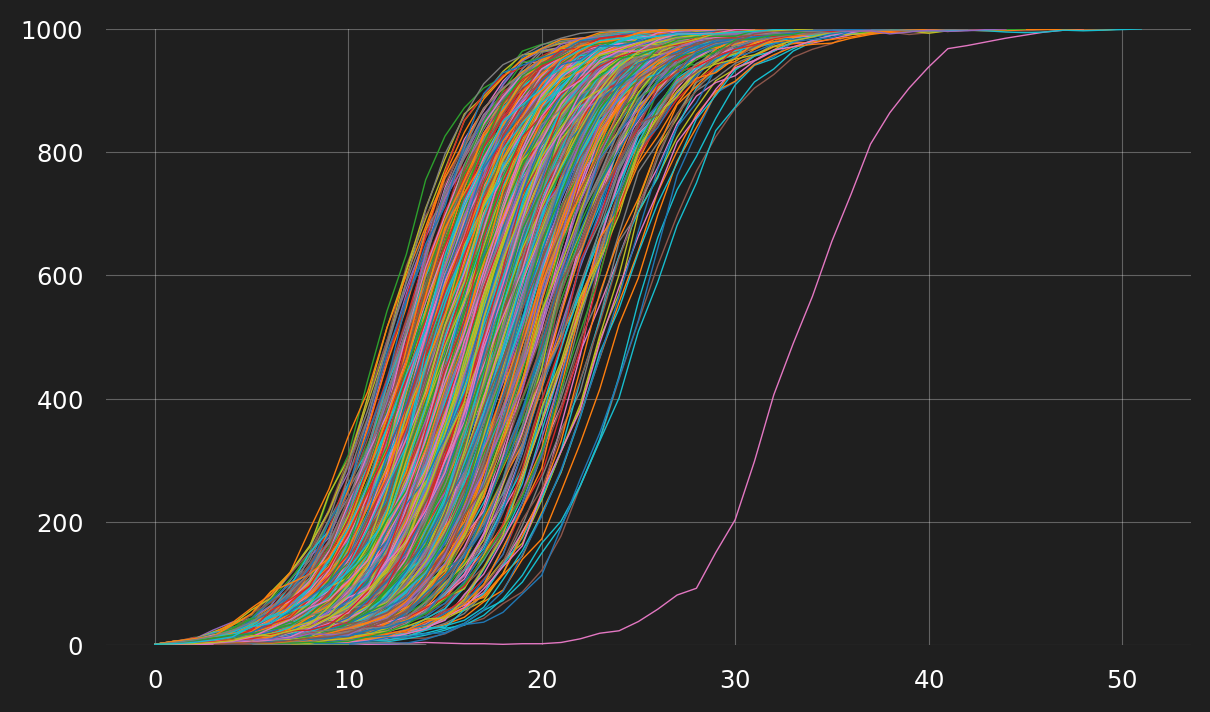

In [41]:
n = 1
N = 1000
s = 0.5
print(f"Ns = {N*s}")
fig = plt.figure(figsize=(7, 4))
plt.ylim(0, N)
for trajectory in freq_trajectory(1000, n=n, s=s, replicates=1000):
    plt.plot(trajectory, lw=0.5)

### Fixation times depend on $N$ (weakly)

For mutations that do fix, how long does it take? Under strong selection ($Ns \gg 1$), the expected fixation time is approximately $\bar{t} \approx 2 \ln(2N) / s$. Note the *logarithmic* dependence on $N$: doubling the population size only adds $\sim 2 \ln 2 / s$ generations to the fixation time. The plots below show the distribution of fixation times (conditional on fixation) for different population sizes, all with the same $s = 0.0005$. The distributions shift to the right with increasing $N$, but only modestly:

In [28]:
%matplotlib inline

In [29]:
def fixation_times(N, n=n, s=s):
    times = list()
    for freqs in freq_trajectory(N, n=n, s=s, replicates=500000):
        if freqs[-1]:
            times.append(len(freqs))
    return times
    
times_2000 = fixation_times(2000, n=1, s=0.0005)
times_5000 = fixation_times(5000, n=1, s=0.0005)
times_10000 = fixation_times(10000, n=1, s=0.0005)
times_100000 = fixation_times(100000, n=1, s=0.0005)

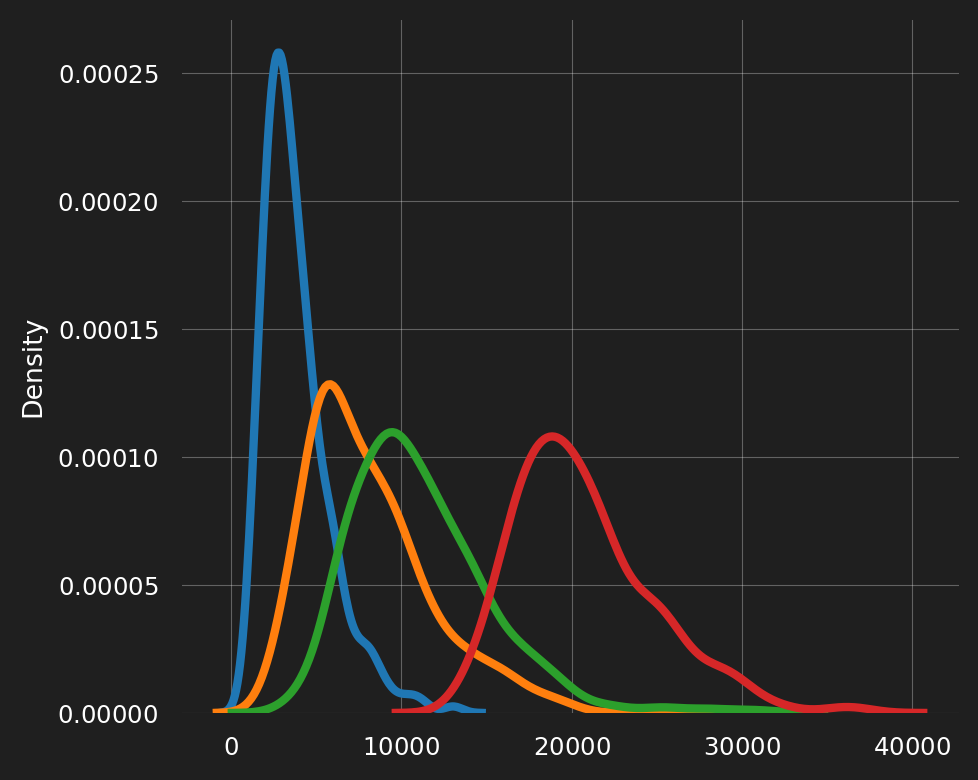

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.kdeplot(times_2000, ax=ax, linewidth=3)
sns.kdeplot(times_5000, ax=ax, linewidth=3)
sns.kdeplot(times_10000, ax=ax, linewidth=3)
sns.kdeplot(times_100000, ax=ax, linewidth=3)
plt.tight_layout()

### Negative selection and drift

What about deleterious mutations ($s < 0$)? Selection acts to remove them, but drift can occasionally push a weakly deleterious allele to higher frequency or even to fixation -- especially in small populations or when $|Ns|$ is small. Below we simulate 1000 new mutations with $s = -0.0001$ in a population of $N = 10{,}000$ (so $Ns = -1$, meaning selection and drift are of comparable magnitude). Most mutations are quickly lost, as expected. But some linger at low frequency for many generations, and rare fixation events can occur. This is the regime of "nearly neutral" evolution, where the boundary between neutral and selected is blurred by drift.

Ns = -1.0


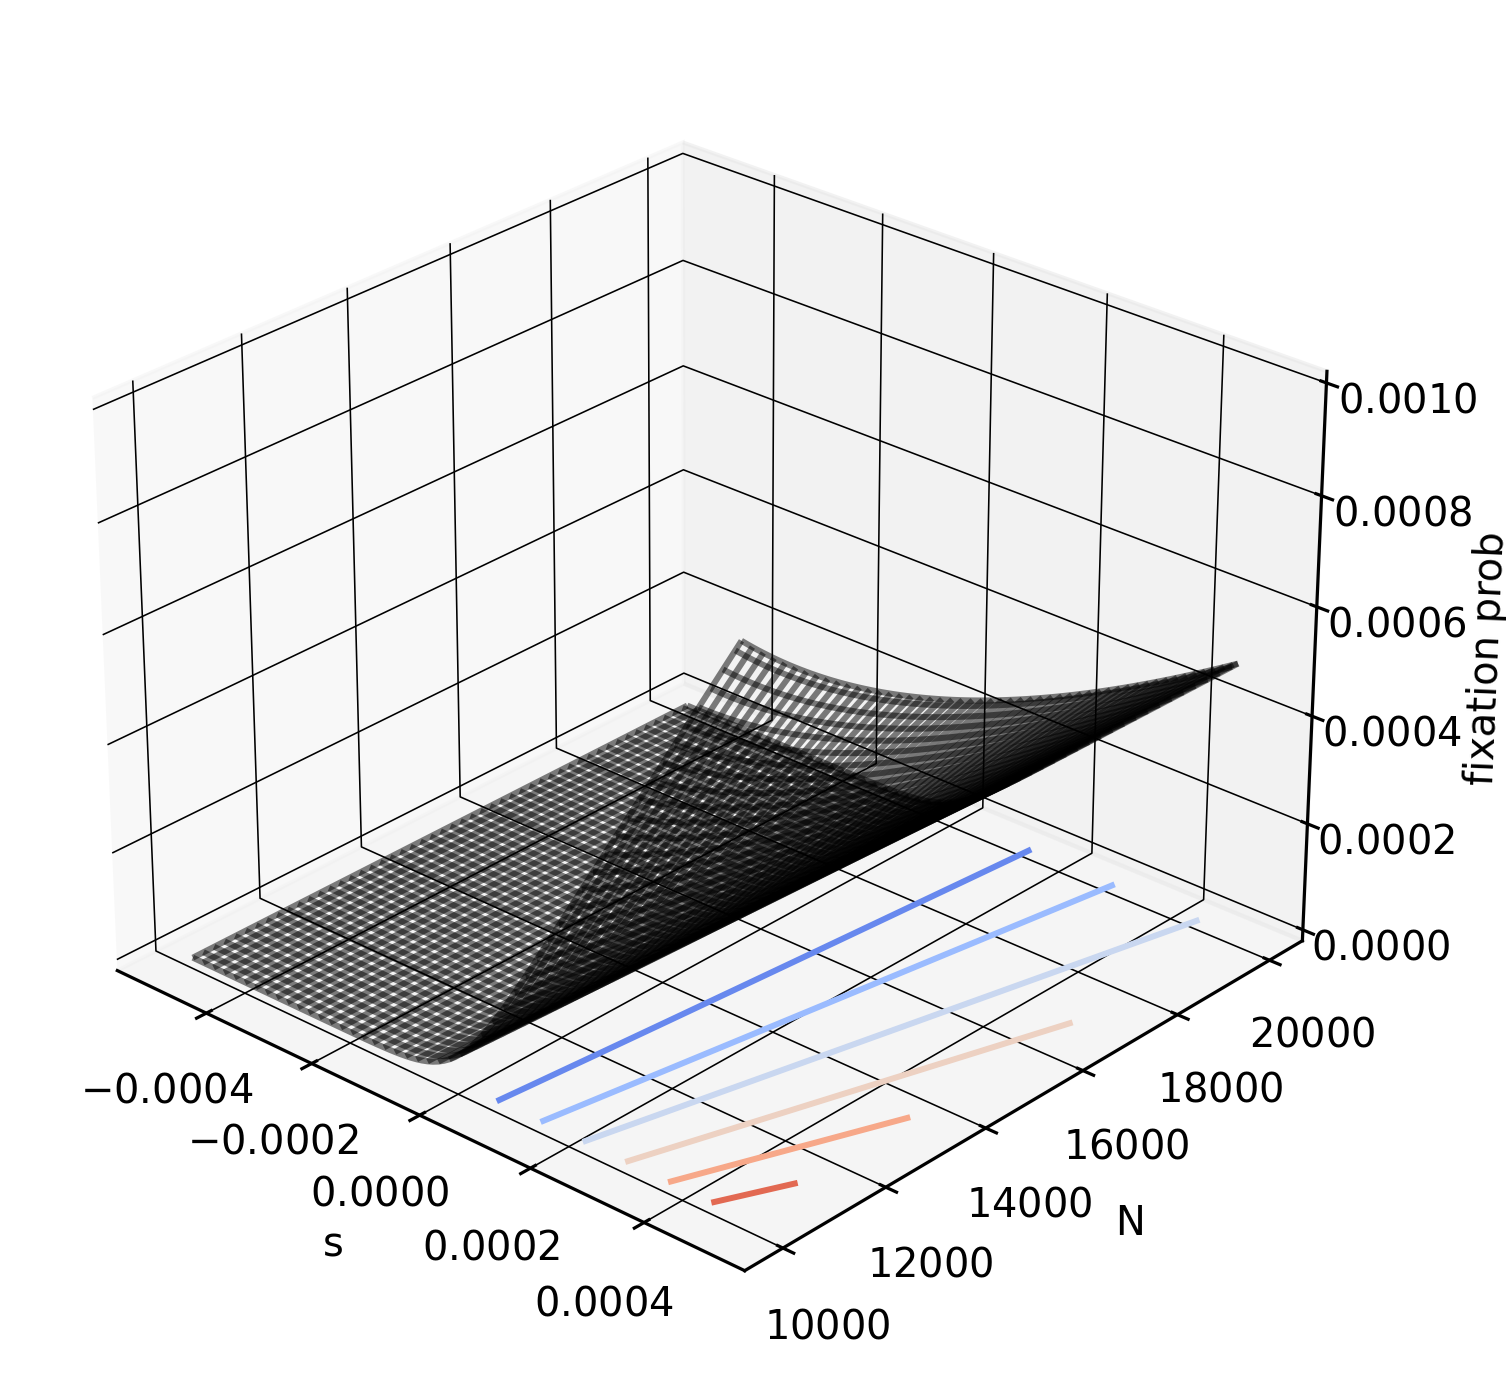

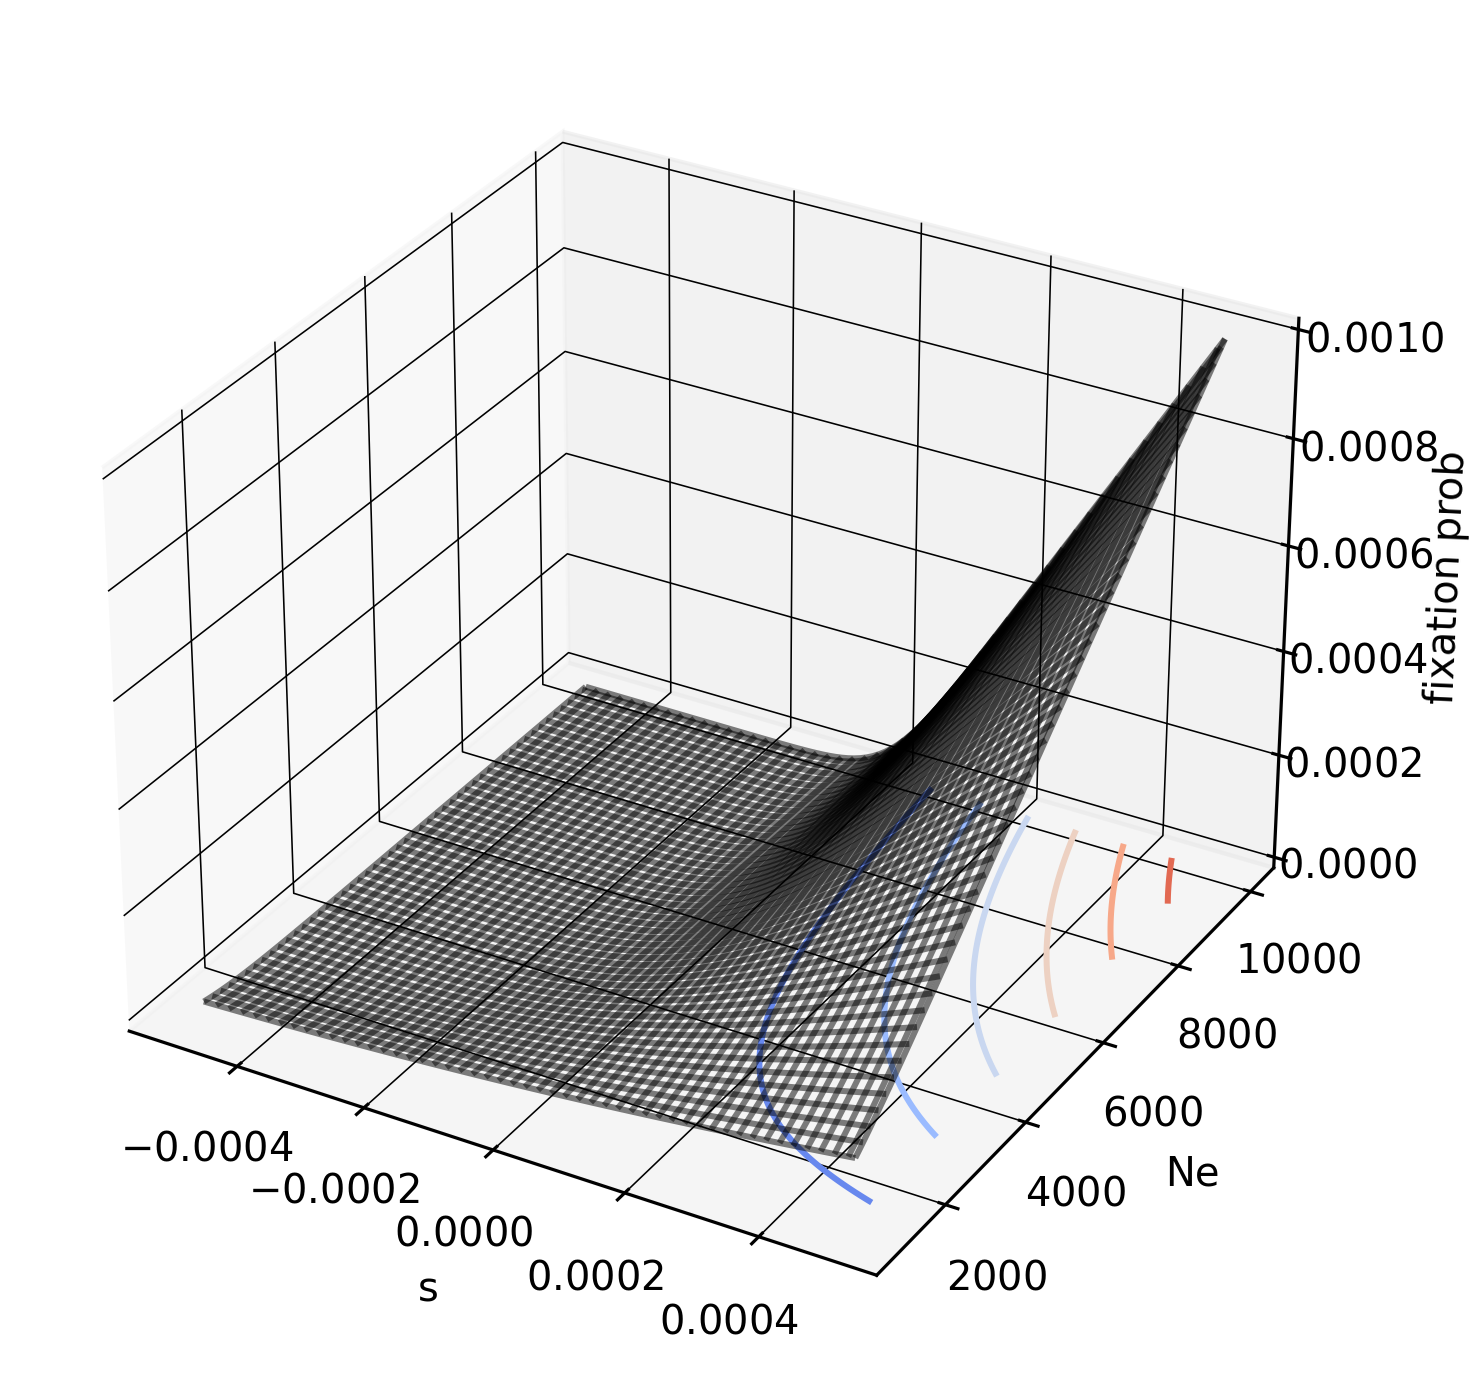

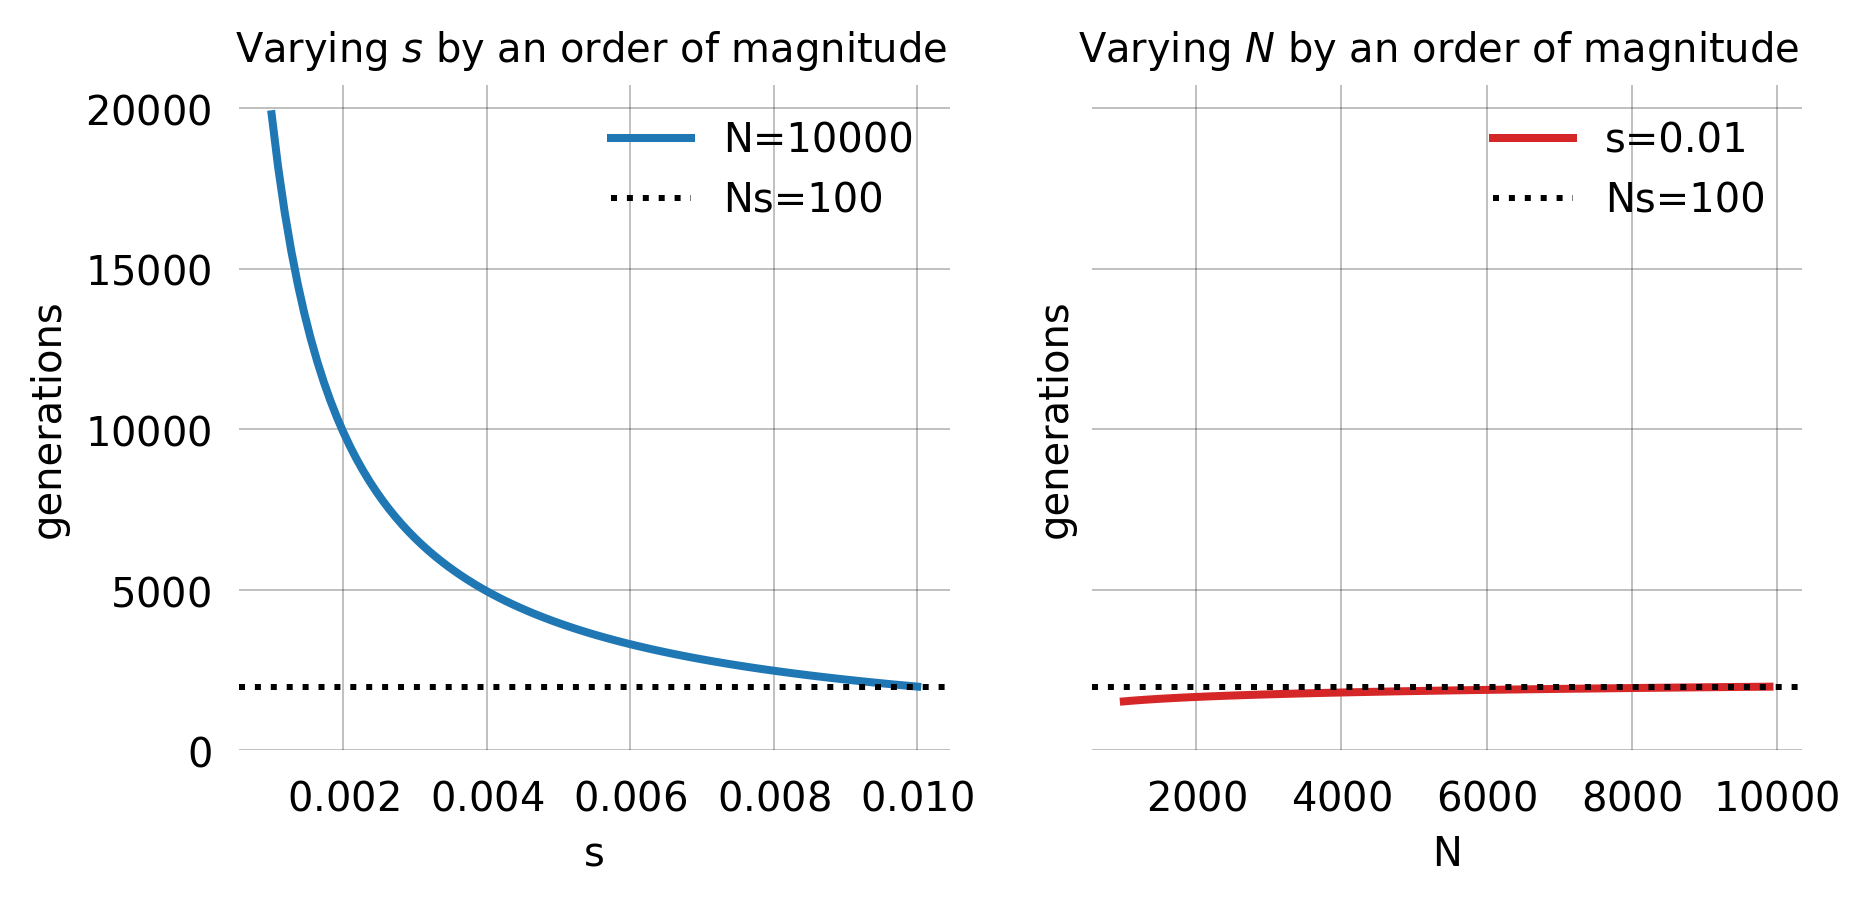

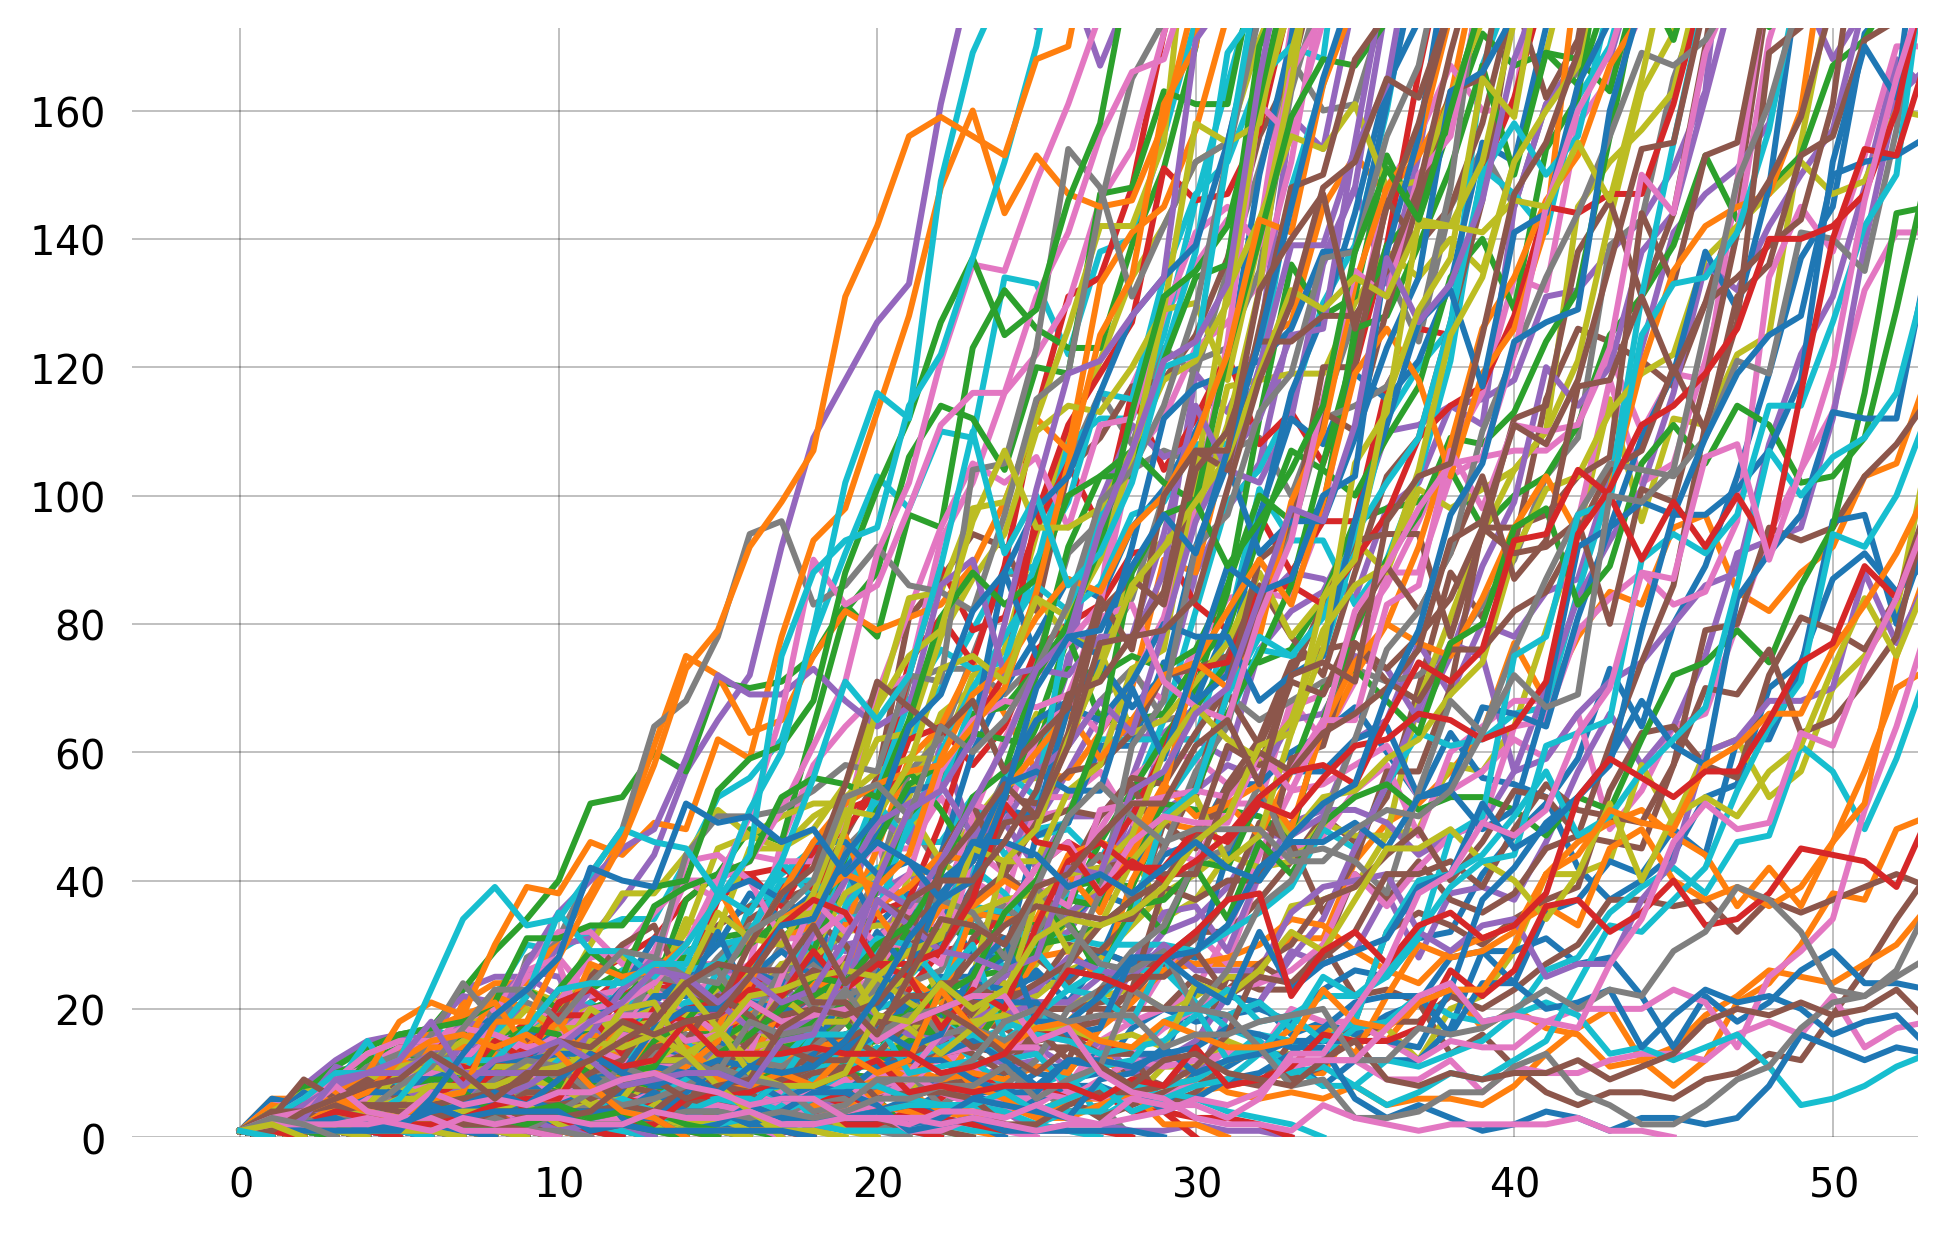

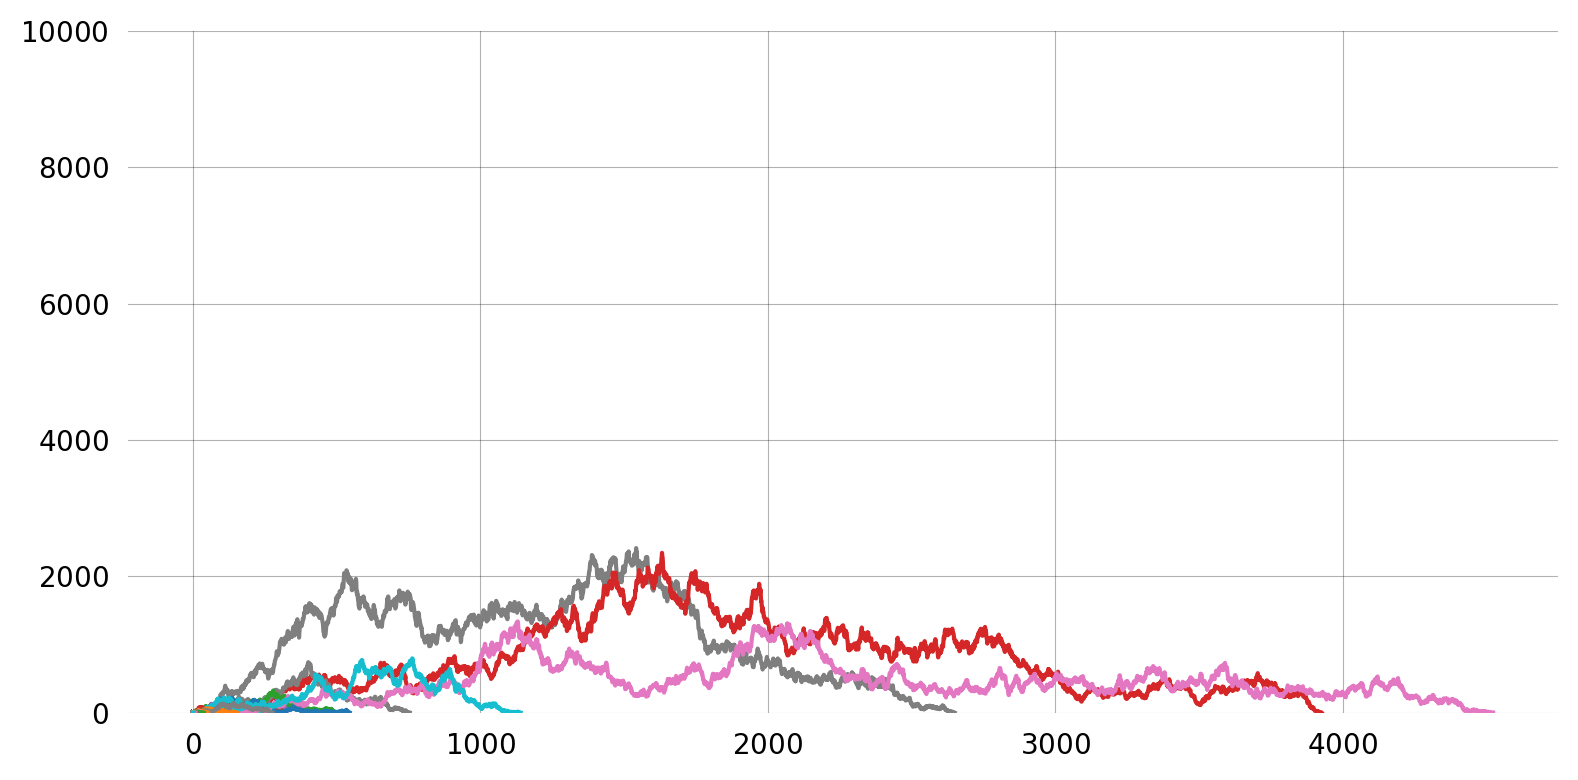

In [39]:
# Number of alleles at onset of selection
n = 1
# Population size (total nr. of alleles)
N = 10000
#N = 100
# selection coeficient
s = -0.0001
print(f"Ns = {N*s}")

fig = plt.figure(figsize=(8, 4))
for i in range(1000):
    plt.plot(list(freq_trajectory(N, n=n, s=s)))
#plt.xlim(0, 1000)
plt.ylim(0, N)
tight(fig)

## Fixation probability

The probability that a new mutation (present in a single copy) ultimately fixes in the population is one of the most important results in population genetics. For a mutation with selective advantage $s$ in a population with effective size $N_e$ and census size $N$, Kimura (1962) derived the diffusion approximation:

$$P_\text{fix} = \frac{1 - \exp(-4sN_e/2N)}{1 - \exp(-4N_es)}$$

For a panmictic population where $N = N_e$, the initial frequency is $1/(2N)$ and this simplifies to:

$$P_\text{fix} = \frac{1 - \exp(-2s)}{1 - \exp(-4 N_e s)}$$

### Approximations for small $s$

When $s$ is small, $1 - \exp(-2s) \approx 2s$, giving the further simplification:

$$P_\text{fix} \approx \frac{2s}{1-\exp(-4 N_e s)}$$

The plot below shows the error of this approximation ($x - (1-e^{-x})$) as a function of $x = 2s$. For $s < 0.05$ the approximation is excellent:

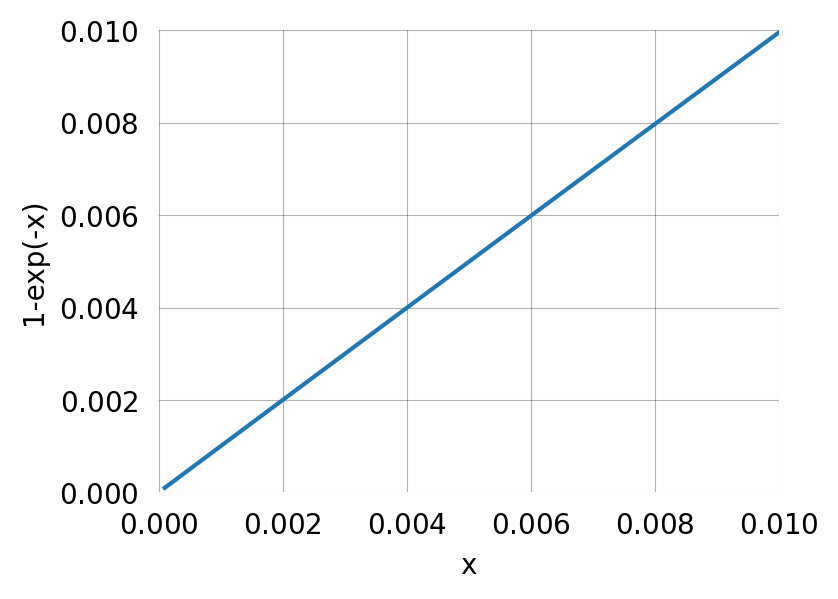

In [23]:
plt.figure(figsize=(4, 3))
x = np.linspace(0.0001, 0.01, 100)
plt.plot(x, (1-np.exp(-x)))
#plt.plot(1-np.exp(-s), 1-np.exp(-s))
plt.xlim(0, 0.01)
plt.ylim(0, 0.01)
plt.ylabel('1-exp(-x)')
plt.xlabel('x') ;

### The $2s$ approximation for strong selection

If we additionally assume that $N_e s \gg 1$ (strong selection), then $\exp(-4 N_e s) \approx 0$ and the denominator approaches 1, giving:

$$P_\text{fix} \approx 2s$$

This is the famous Haldane (1927) result: a beneficial mutation with selective advantage $s$ in a large population fixes with probability approximately $2s$. The plot below shows $1 - e^{-x}$ as a function of $x = 4N_es$. Once $4N_e s > 3$ or so, the function is close to 1 and the $2s$ approximation holds:

Text(0.5, 0, 'x')

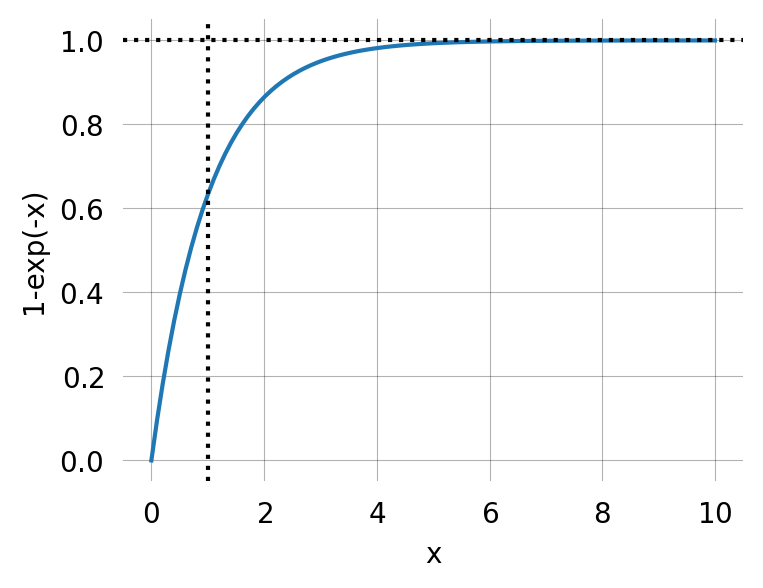

In [18]:
plt.figure(figsize=(4, 3))
x = np.linspace(0.0001, 10, 100)
plt.plot(x, 1-np.exp(-x))
plt.axvline(1, color='black', linestyle='dotted')
plt.axhline(1, color='black', linestyle='dotted')
plt.ylabel('1-exp(-x)')
plt.xlabel('x')

In [24]:
def prob_fixation(s, Ne, N):
    return (1 - np.exp(-4*s*Ne/(2*N))) / (1 - np.exp(-4 * Ne * s))

def simple_prob_fixation(s, N):
    return (1 - np.exp(-2*s)) / (1 - np.exp(-4 * N * s))

def simplest_prob_fixation(s, N):
    return 2*s / (1 - np.exp(-4 * N * s))

nr_points = 100

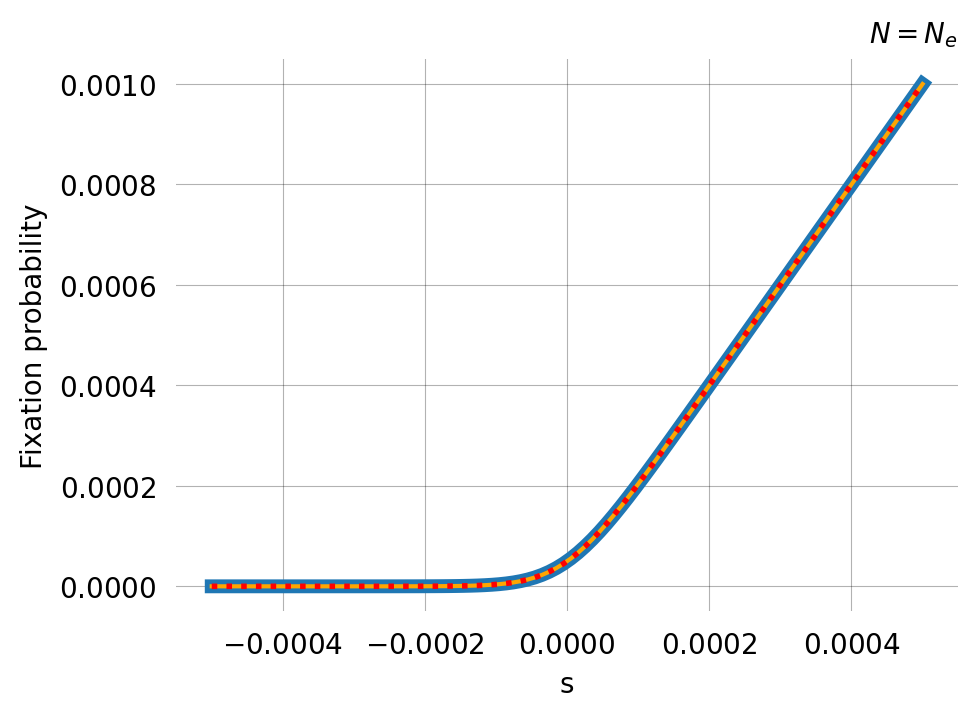

In [25]:
Ne = 10000
N = Ne
max_s = 0.0005

s_arr = np.linspace(-max_s, max_s, num=nr_points)
Ne_arr = np.full(nr_points, Ne)
N_arr = np.full(nr_points, N)

fig, (ax1) = plt.subplots(1, 1)

ax1.plot(s_arr, prob_fixation(s_arr, Ne_arr, N_arr), linewidth=5)
ax1.plot(s_arr, simple_prob_fixation(s_arr, Ne_arr), color='orange')
ax1.plot(s_arr, simplest_prob_fixation(s_arr, Ne_arr), color='red', linestyle='dotted', linewidth=2)
ax1.set_xlabel('s')
ax1.set_ylabel('Fixation probability')
ax1.set_title('$N = N_e$')
tight(fig)

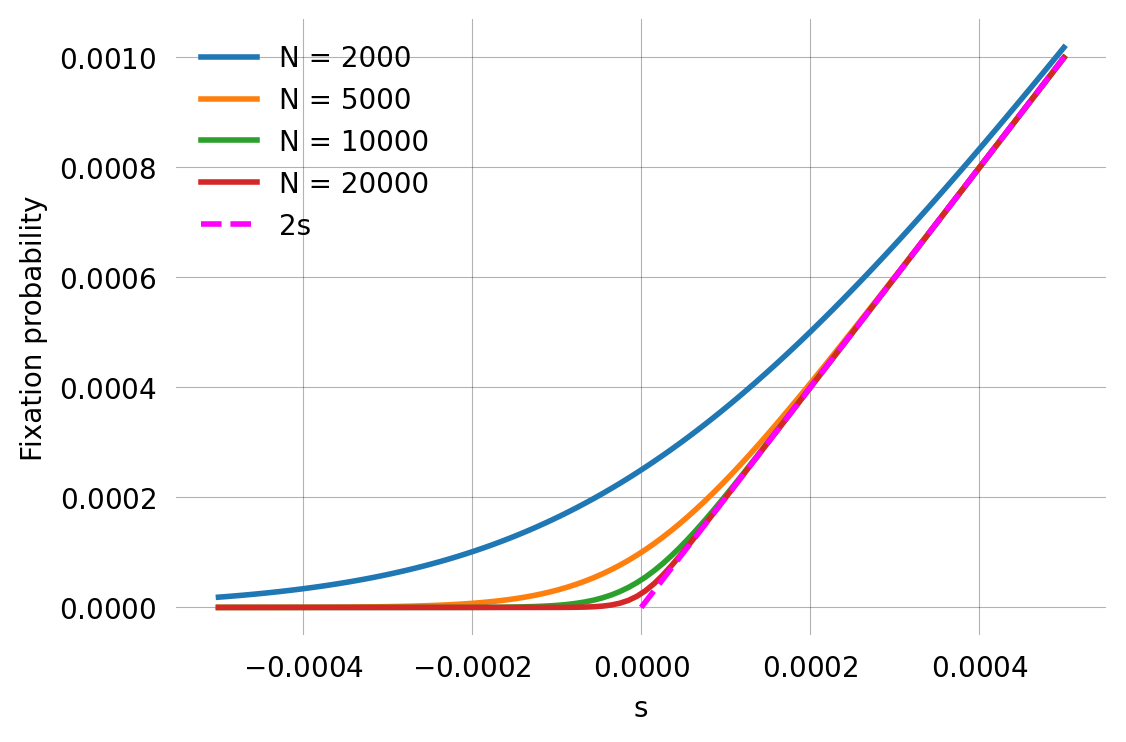

In [26]:
nr_points = 100
Ne = 10000
N = Ne
max_s = 0.0005
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for Ne in [2000, 5000, 10000, 20000]:
    N = Ne
    plt.plot(s_arr, prob_fixation(np.linspace(-max_s, max_s, num=nr_points), np.full(nr_points, Ne), np.full(nr_points, N)), label=f'N = {Ne}', linewidth=2)
plt.plot(np.linspace(0, max_s, 2), np.linspace(0, max_s, 2)*2, linestyle='dashed', color='magenta', linewidth=2, label='2s')
plt.legend()
plt.xlabel('s')
plt.ylabel('Fixation probability')  ;

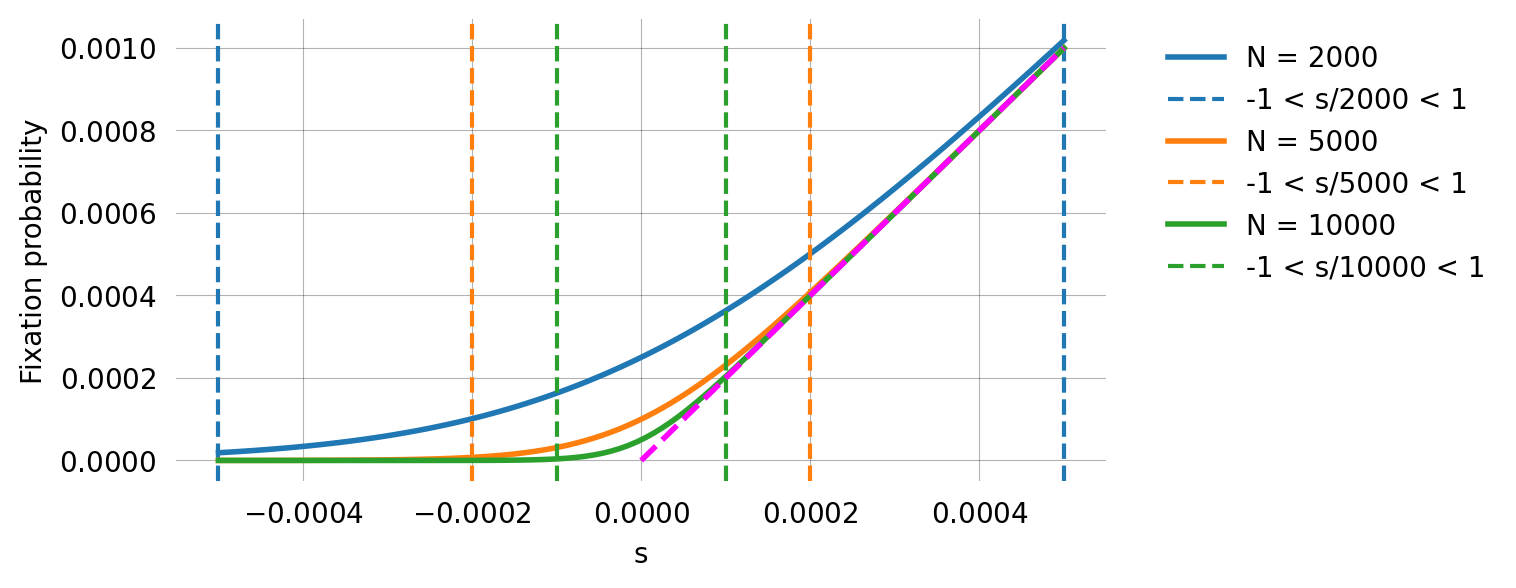

In [27]:
nr_points = 100
Ne = 10000
N = Ne
max_s = 0.0005
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i, Ne in enumerate([2000, 5000, 10000]):
    N = Ne
    plt.plot(s_arr, prob_fixation(np.linspace(-max_s, max_s, num=nr_points), np.full(nr_points, Ne), np.full(nr_points, N)), label=f'N = {Ne}', linewidth=2, color=f'C{i}')
    plt.axvline(x=1/Ne, linestyle='dashed', color=f'C{i}', label=f'-1 < s/{Ne} < 1')
    plt.axvline(x=-1/Ne, linestyle='dashed', color=f'C{i}')

plt.plot(np.linspace(0, max_s, 2), np.linspace(0, max_s, 2)*2, linestyle='dashed', color='magenta', linewidth=2)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.xlabel('s')
plt.ylabel('Fixation probability') ;

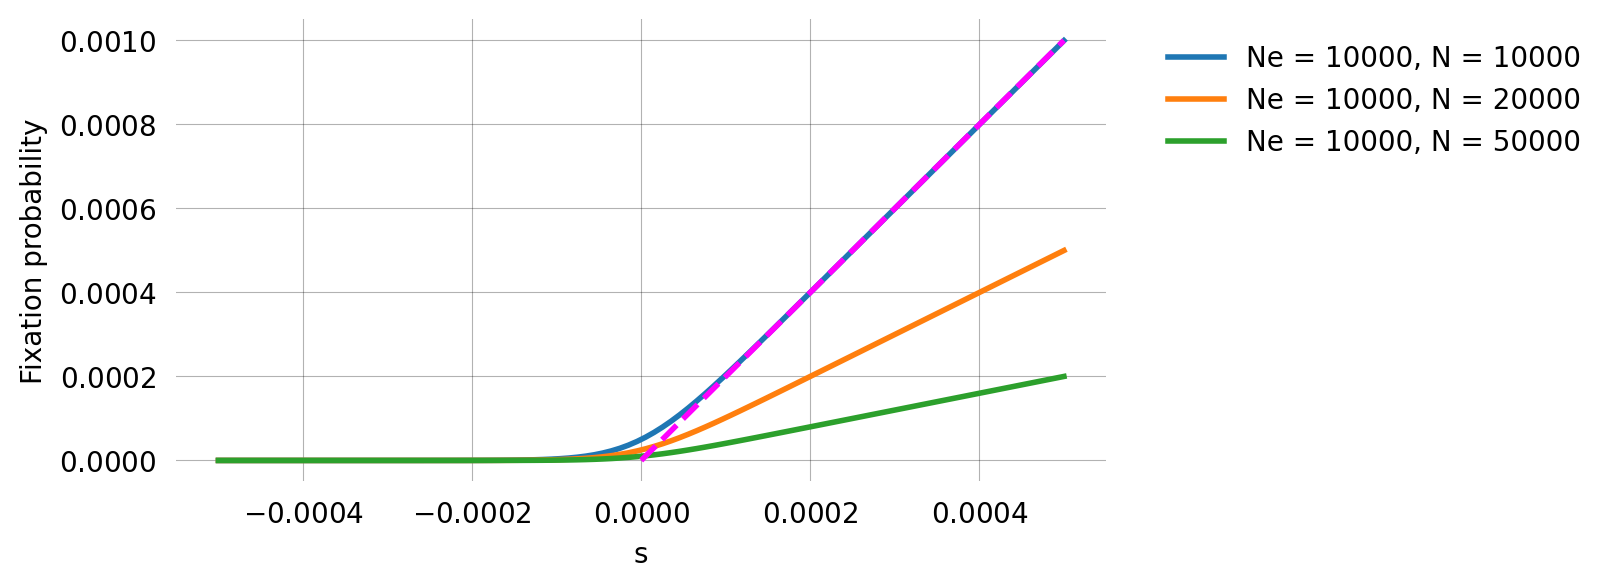

In [28]:
nr_points = 100
Ne = 10000
max_s = 0.0005
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i, N in enumerate([10000, 20000, 50000]):
    plt.plot(s_arr, prob_fixation(np.linspace(-max_s, max_s, num=nr_points), np.full(nr_points, Ne), np.full(nr_points, N)), label=f'Ne = {Ne}, N = {N}', linewidth=2, color=f'C{i}')
    # plt.axvline(x=1/Ne, linestyle='dashed', color=f'C{i}', label=f'-1 < s/{Ne} < 1')
    # plt.axvline(x=-1/Ne, linestyle='dashed', color=f'C{i}')

plt.plot(np.linspace(0, max_s, 2), np.linspace(0, max_s, 2)*2, linestyle='dashed', color='magenta', linewidth=2)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.xlabel('s')
plt.ylabel('Fixation probability') ;

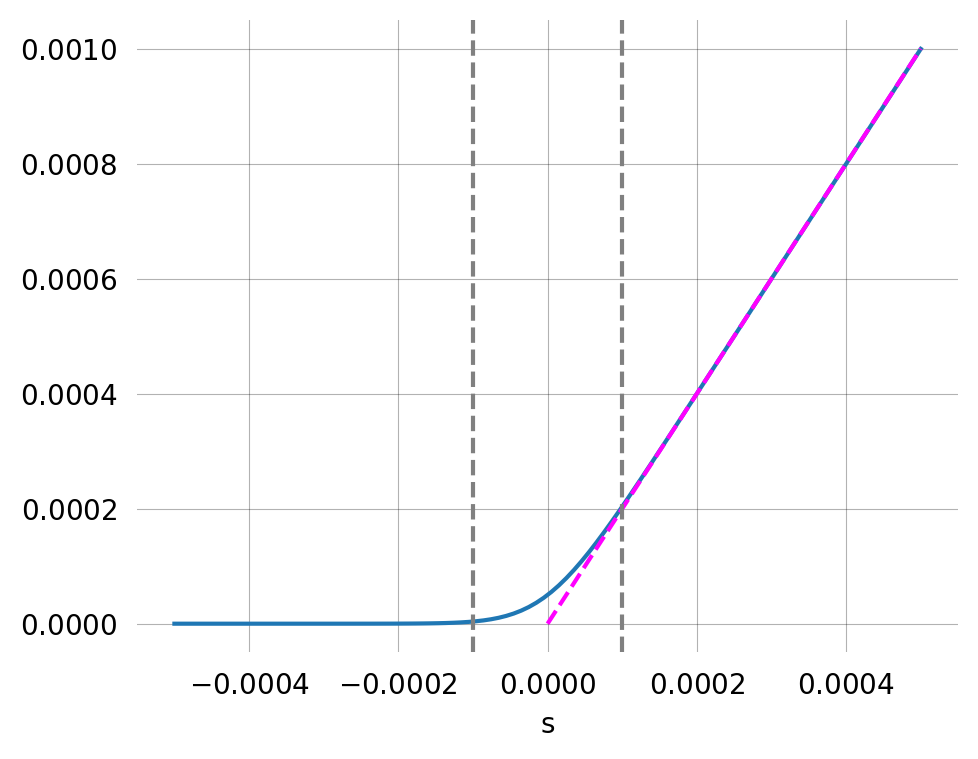

In [29]:
nr_points = 100
Ne = 10000
N = Ne
max_s = 0.0005

fig, ax = plt.subplots(1, 1)
s_arr = np.linspace(-max_s, max_s, num=nr_points)
Ne_arr = np.full(nr_points, Ne)
N_arr = np.full(nr_points, N)

plt.plot(s_arr, prob_fixation(s_arr, Ne_arr, N_arr))
plt.plot(np.linspace(0, max_s, 2), np.linspace(0, max_s, 2)*2, c='magenta', linestyle='dashed')

#ax.add_patch(Rectangle((-1/Ne, 0), 2/Ne, 0.001, alpha=0.2, color='grey', zorder=0))

plt.axvline(x=1/Ne, linestyle='dashed', color='grey')
plt.axvline(x=-1/Ne, linestyle='dashed', color='grey')
plt.tight_layout()

plt.xlabel('s') ;

### Effect of $N \neq N_e$ (non-panmictic populations)

In real populations, the effective population size $N_e$ is often smaller than the census size $N$ due to population structure, unequal sex ratios, variance in reproductive success, and fluctuations in population size. This matters for fixation probabilities because the initial frequency of a new mutation is $1/(2N)$ (determined by census size), but the strength of drift is governed by $N_e$. When $N > N_e$, a new mutation starts at a lower frequency than drift alone would suggest, reducing its fixation probability. The left panel below shows the panmictic case ($N = N_e$), while the right panel shows $N = 2 N_e$. Notice how the fixation probability curve is compressed downward:

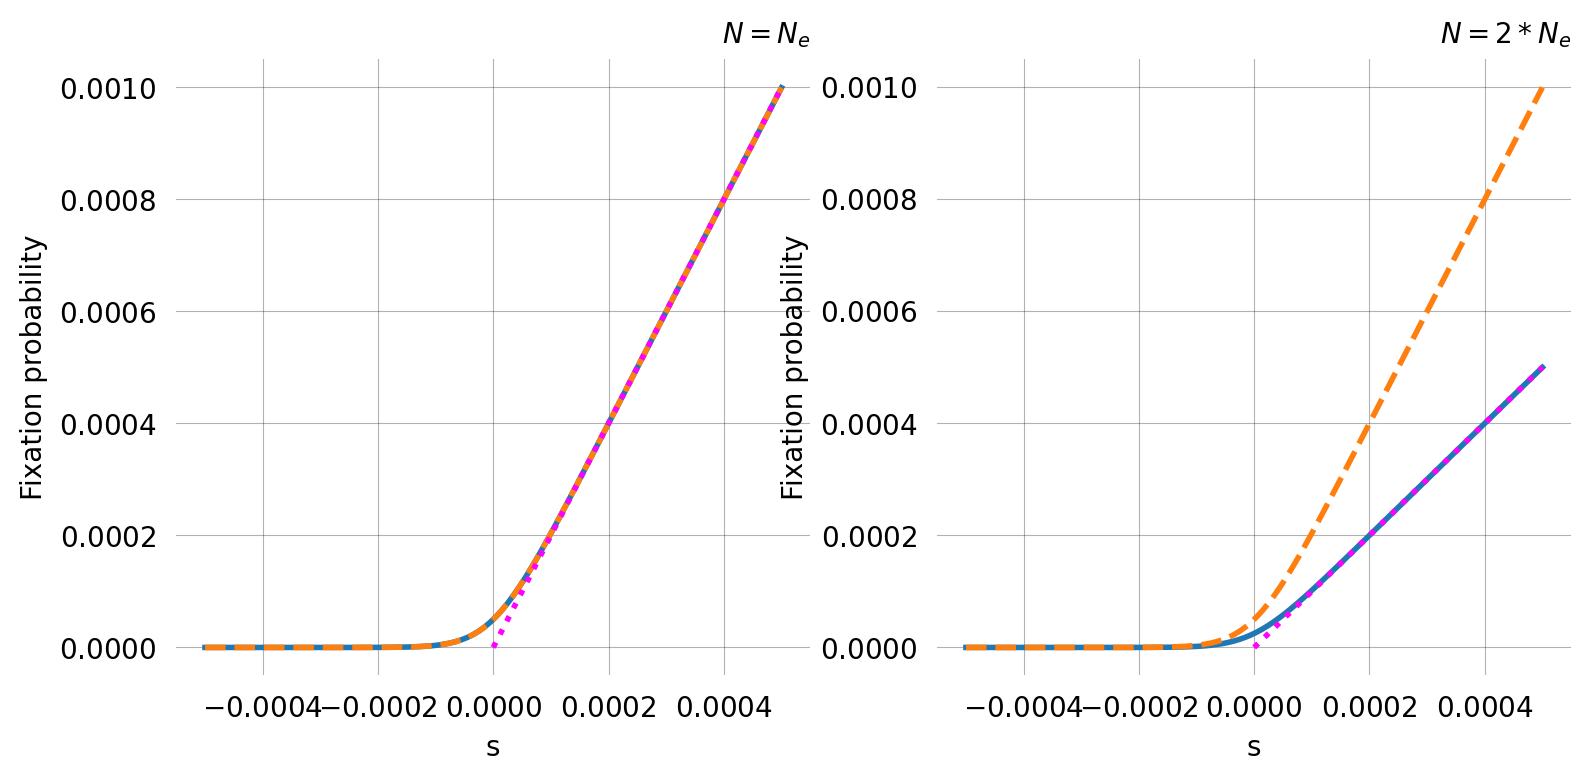

In [30]:
Ne = 10000
N = Ne
max_s = 0.0005

s_arr = np.linspace(-max_s, max_s, num=nr_points)
Ne_arr = np.full(nr_points, Ne)
N_arr = np.full(nr_points, N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
lw = 2
ax1.plot(s_arr, prob_fixation(s_arr, Ne_arr, N_arr), c='C0', linewidth=lw)
ax1.plot(s_arr, simple_prob_fixation(s_arr, Ne_arr), color='C1', linestyle='dashed', linewidth=lw)
ax1.set_xlabel('s')
ax1.set_ylabel('Fixation probability')
ax1.set_title('$N = N_e$')

ax2.plot(s_arr, prob_fixation(s_arr, Ne_arr, N_arr*2), c='C0', linewidth=lw)
ax2.plot(s_arr, simple_prob_fixation(s_arr, Ne_arr), color='C1', linestyle='dashed', linewidth=lw)
ax2.set_xlabel('s')
ax2.set_ylabel('Fixation probability')
ax2.set_title('$N = 2 * N_e$')

ax1.plot(np.linspace(0, max_s, 2), np.linspace(0, max_s, 2)*2, linestyle='dotted', color='magenta', linewidth=lw)
ax2.plot(np.linspace(0, max_s, 2), np.linspace(0, max_s, 2)*2/2, linestyle='dotted', color='magenta', linewidth=lw) ;

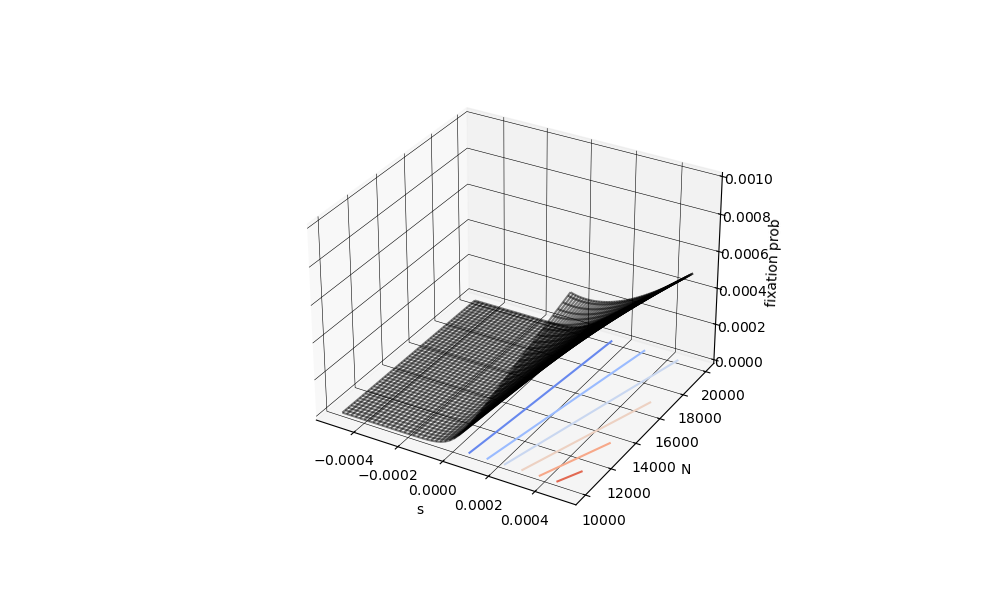

In [32]:
%matplotlib widget
Ne = 10000
N = Ne
max_s = 0.0005

s_arr = np.linspace(-max_s, max_s, num=nr_points)
Ne_arr = np.full(nr_points, Ne)
N_arr = np.full(nr_points, N)

_s = np.repeat(s_arr, nr_points).reshape((nr_points, nr_points)).transpose()
_N = np.repeat(np.linspace(10000, 20000, num=nr_points), nr_points).reshape((nr_points, nr_points))
_Ne = np.repeat(Ne_arr, nr_points).reshape((nr_points, nr_points))
_f = prob_fixation(_s, _Ne, _N)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(_s, _N, _f, alpha=0.5, color='black')
#ax.plot_surface(_s, _N, _f, alpha=0.5, color='black')
ax.contour(_s, _N, _f, zdir='z', offset=0, cmap=cm.coolwarm)
ax.set_xlabel('s')
ax.set_ylabel('N')
ax.set_zlabel('fixation prob') ;

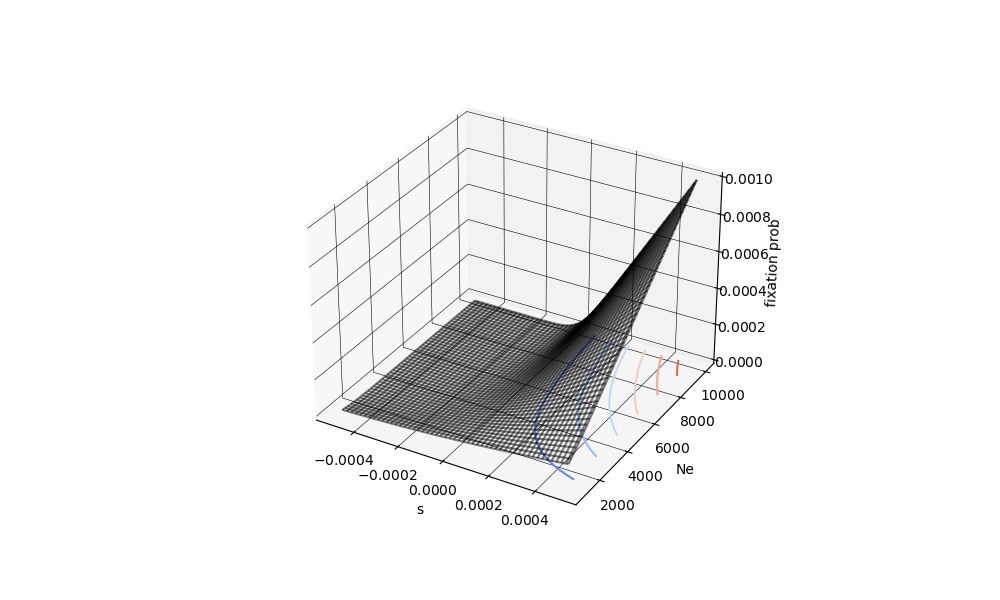

In [33]:

_s = np.repeat(s_arr, nr_points).reshape((nr_points, nr_points)).transpose()
_N = np.repeat(N_arr, nr_points).reshape((nr_points, nr_points))
_Ne = np.repeat(np.linspace(1000, 10000, num=nr_points), nr_points).reshape((nr_points, nr_points))
_f = prob_fixation(_s, _Ne, _N)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(_s, _Ne, _f, alpha=0.5, color='black')
#ax.plot_surface(_s, _Ne, _f, alpha=0.2, color='grey')
ax.contour(_s, _Ne, _f, zdir='z', offset=0, cmap=cm.coolwarm)
ax.set_xlabel('s')
ax.set_ylabel('Ne')
ax.set_zlabel('fixation prob') ;

The 3D surface plots above show how fixation probability depends jointly on $s$ and population size parameters. Compare to the 2D slices shown earlier for fixed $N_e$. The key takeaway: fixation probability is a smooth function of $s$, transitioning from the neutral expectation $1/(2N)$ when $|N_e s| < 1$ to the deterministic regime $\approx 2s$ when $N_e s \gg 1$. The transition zone around $|N_e s| \approx 1$ is where drift and selection are of comparable magnitude -- this is the "nearly neutral" zone that plays a central role in molecular evolution.

## Strong selection

When $N_e s \gg 1$, selection dominates over drift for most of the allele's trajectory (except at the very beginning and very end). In this regime, the frequency trajectory of a beneficial allele that escapes initial loss closely follows a deterministic logistic curve. We now examine the expected shape of this trajectory and the time it takes for a strongly selected allele to sweep to fixation.

### Fixation time under strong selection

Under strong selection ($N_e s \gg 1$), the expected fixation time for a new mutation (starting at frequency $1/(2N)$) is:

$$\bar{t} \approx \frac{2 \ln (2N_e)}{s}$$

This formula has two important properties: (1) fixation time is inversely proportional to $s$ -- doubling the selective advantage halves the time to fixation, and (2) it depends only *logarithmically* on $N$, so population size has a relatively minor effect on sweep duration. The left plot below varies $s$ by an order of magnitude at fixed $N$; the right plot varies $N$ by an order of magnitude at fixed $s$. Notice how the fixation time is much more sensitive to changes in $s$ than to changes in $N$:

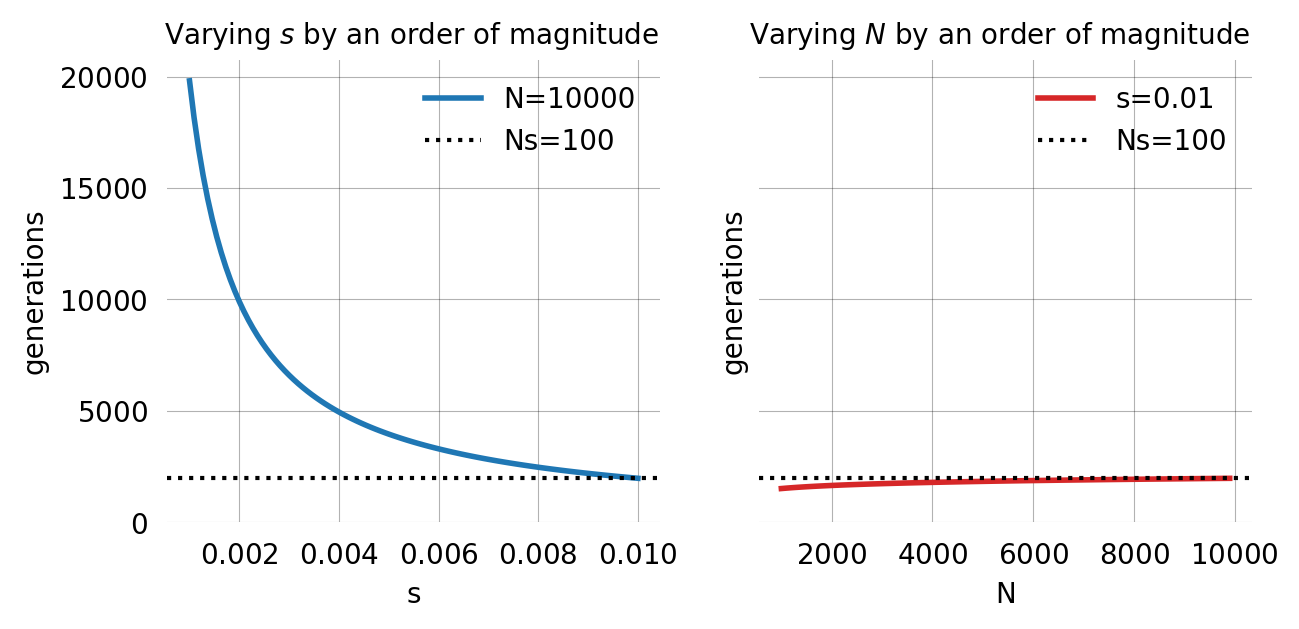

In [40]:
def fixation_time(s, N):
    return 2 * math.log(2*N) / s


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
s_list = np.linspace(0.001, 0.01, 100)
N = 10000
ax1.plot(s_list, [fixation_time(s, N) for s in s_list], linewidth=2, color='C0', label=f'N={N}')
ax1.axhline(fixation_time(s_list[-1], N), linestyle='dotted', color='black', label='Ns=100')
ax1.set_xlabel('s')
ax1.set_ylabel('generations')
ax1.legend(frameon=False)
ax1.set_title('Varying $s$ by an order of magnitude ')


s=0.01
N_list = range(1000, 10000, 100)
ax2.plot(N_list, [fixation_time(s, N) for N in N_list], linewidth=2, color='C3', label=f's={s}')
ax2.axhline(fixation_time(s, N_list[-1]), linestyle='dotted', color='black', label='Ns=100')
ax2.set_xlabel('N')
ax2.set_ylabel('generations')
ax2.legend(frameon=False)
ax2.set_title('Varying $N$ by an order of magnitude ')

ax2.set_ylim(bottom=0) ;

### Deterministic trajectory (logistic growth)

Under strong selection, the frequency of a beneficial allele over time follows a logistic curve. If $f_A(0) = p$ is the initial frequency and $s$ is the selective advantage, the deterministic trajectory is:

$$ f_A(t) = \frac{p}{p + (1-s)^t (1-p)}$$

This is an S-shaped (sigmoidal) curve: the allele rises slowly when rare (exponential growth phase), accelerates through intermediate frequencies, and slows again as it approaches fixation. The logistic approximation matches the exact haploid trajectory very closely:

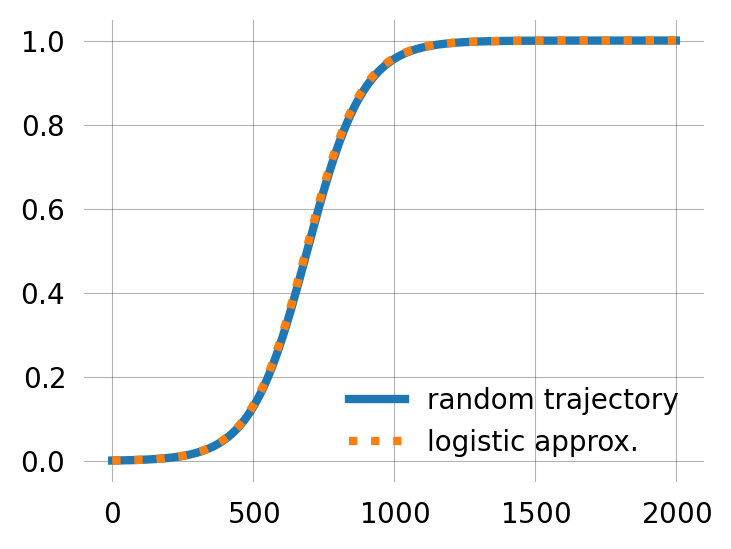

In [41]:
# # Number of alleles at onset of selection
# n = 1
# # Population size (total nr. of alleles)
# N = 10000
# # selection coeficient
# s = 0.01

def logistic_function(t, s, p):
    return p / (p + (1-s)**t * (1-p))

def haploid_trajectory(t, s, p):
    # ts = -(2/(2*N*s)) * np.log(p)    
    # return p / (p + (1-p) * np.exp(-s*(t-(-(2/(2*N*s)) * np.log(p)))))
    return (1/(N))/(1/(N) + (  1 - 1/(N)) * np.exp(-s*(t+np.log(2/(N)) / (N*s) )))


fig = plt.figure(figsize=(4, 3))

N = 1000
s = 0.01
plt.plot([haploid_trajectory(x, s, 1/N) for x in range(2000)], linewidth=3, color='C0', label='random trajectory')
plt.plot([logistic_function(x, s, 1/N) for x in range(2000)], linewidth=3, color='C1', linestyle='dotted', label='logistic approx.') ;
plt.legend(frameon=False) ;

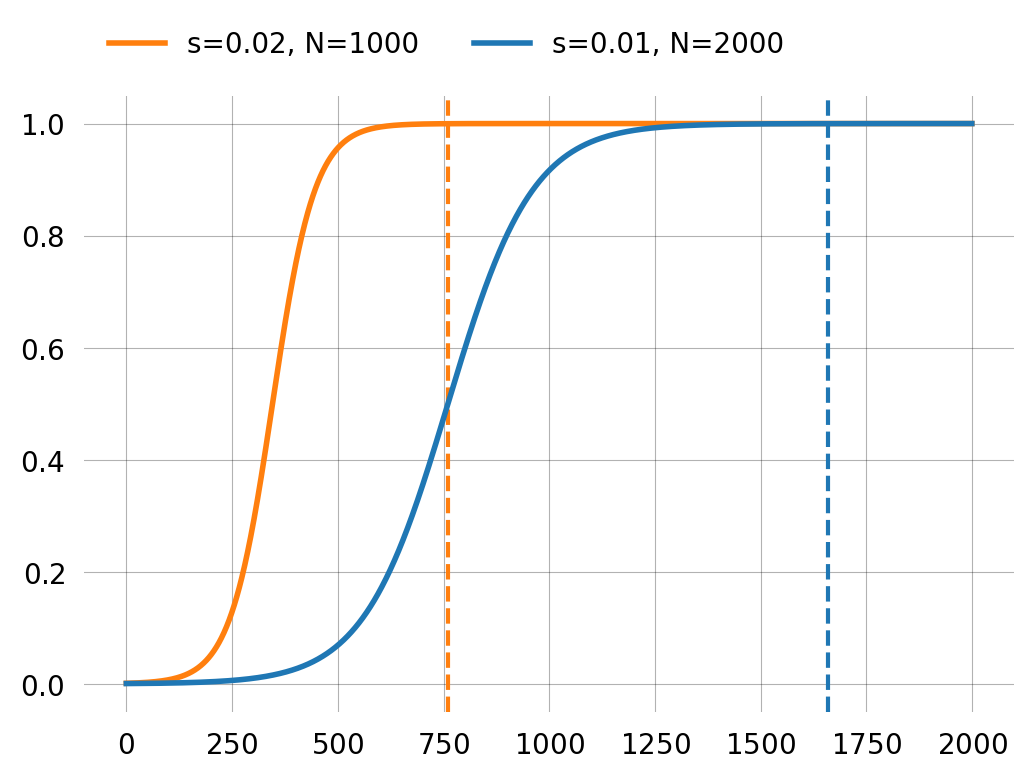

In [42]:
fig = plt.figure(figsize=(6, 4))

N = 1000
s = 0.02
plt.plot([haploid_trajectory(x, s, 1/N) for x in range(2000)], linewidth=2, color='C1', label='s=0.02, N=1000')
plt.axvline(fixation_time(s, N), color='C1', linestyle='dashed')

N = 2000
s = 0.01
plt.plot([haploid_trajectory(x, s, 1/N) for x in range(2000)], linewidth=2, color='C0', label='s=0.01, N=2000')
plt.axvline(fixation_time(s, N), color='C0', linestyle='dashed')
plt.legend(frameon=False, bbox_to_anchor=(0, 1.02, 1, .02), loc="lower left", ncol=2)

### Stochastic trajectories under strong selection

Even under strong positive selection, most new beneficial mutations are lost. This is a crucial point: natural selection is probabilistic, not deterministic. Below we simulate 100 new mutations with $s = 0.01$ in a population of $N = 10{,}000$ (so $Ns = 100$). The expected fixation probability is $\approx 2s = 0.02$, meaning only about 2 out of every 100 beneficial mutations will fix. Among those that do fix, notice how their trajectories closely follow the deterministic logistic curve. Stochasticity matters most at the two extremes: when the allele is very rare (risk of loss) and when it is very common (slow final approach to fixation). In between, selection is the dominant force and the trajectory is nearly deterministic.

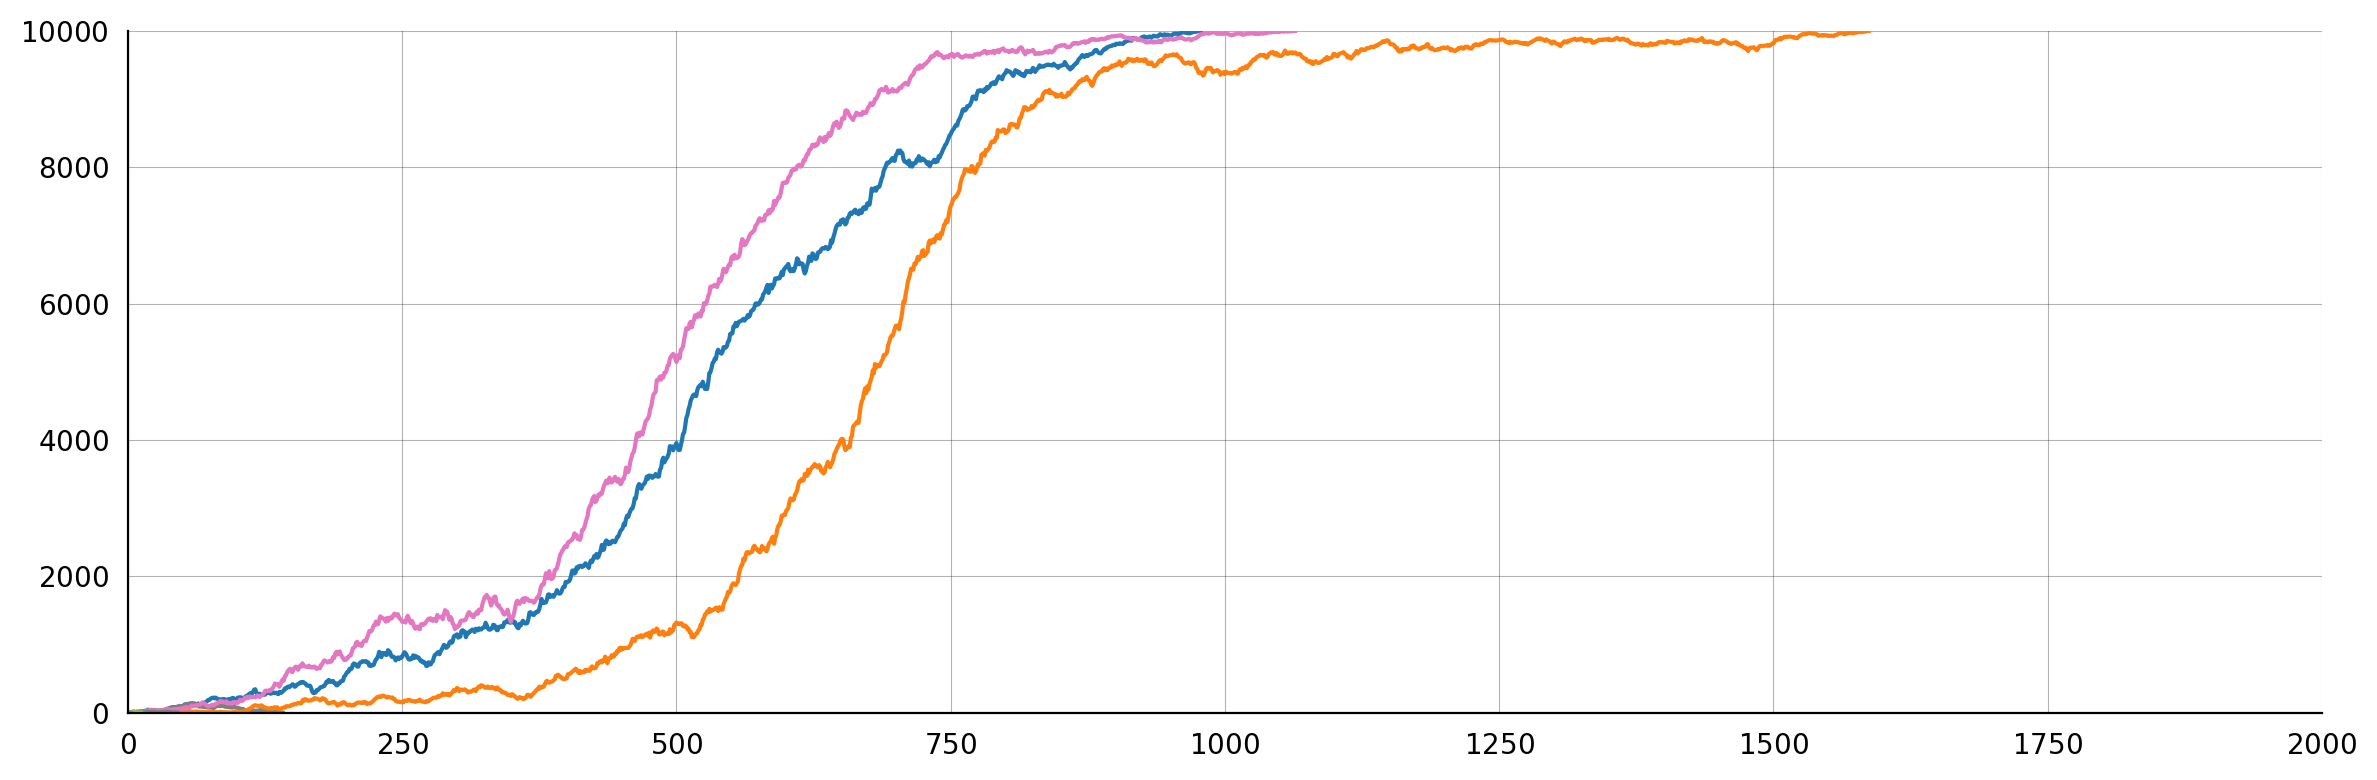

In [43]:
# Number of alleles at onset of selection
n = 1
# Population size (total nr. of alleles)
N = 10000
# selection coeficient
s = 0.01

# try out:
# N=100, s=0.01, 
# N=10000, s=0.001, N=10000, s=0.01

fig = plt.figure(figsize=(12, 4))
for i in range(100):
    plt.plot(list(freq_trajectory(N, n=n, s=s)))
plt.xlim(0, 2000)
plt.ylim(0, 10000)
sns.despine()
tight(fig)
plt.savefig('strong_s_trajectories.pdf')

In [44]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 4), sharey=True)

# fix_time = fixation_time(0.01, 10000) 

# g = np.linspace(fix_time, 1, 100)

# ax1.plot([1 - logistic_function(x, 0.01, 1/10000) for x in g], g, linewidth=2, color='C3', label='Frequency of\nselected variant')
# ax1.fill_between([1 - logistic_function(x, 0.01, 1/10000) for x in g], g, alpha=0.1, color='C3')
# ax1.set_ylim((0, 4000))
# ax1.set_ylabel('Generations ago')
# ax1.set_xlabel('Frequency')
# ax1.legend(frameon=False)
# ax1.spines[['top']].set_visible(False)


# ax1.set_xlim((-0.01, 1.01))
# ax2.plot([1 - logistic_function(x, 0.01, 1/10000) for x in g], g, linewidth=2, color='C3')
# ax2.fill_between([1 - logistic_function(x, 0.01, 1/10000) for x in g], g, alpha=0.1, color='C3')
# ax2.set_ylim((0, 4000))
# ax2.set_xlim((-0.01, 1.01))
# ax2.set_xlabel('Frequency')
# ax2.spines[['top']].set_visible(False)
# plt.tight_layout()
# # plt.axhline(fix_time, linestyle='dashed', color='black',)
# # plt.legend(frameon=False)
# plt.savefig('sweep_escape.pdf')